# Agentic Memory Atomicity:
# A Transactional Memory Architecture for Ephemeral AI Agent Systems

**Loïc Mancino** · **Jérôme Chincarini**

*Synergix Labs — 1 year of R&D on [wrai.th](https://wrai.th)*

---

**Abstract** — We present *Agentic Memory Atomicity*, an architecture where AI agents are stateless ephemeral processes that read from and commit to a persistent, transactional memory store. Each agent spawns, loads inherited knowledge, performs work, commits new knowledge atomically, and terminates. The next spawn inherits everything. We formalize the state model, demonstrate monotonic knowledge growth under compaction, and show sub-linear cost scaling for multi-agent teams sharing project-scoped memory. Our implementation (relay OS) uses SQLite with FTS5, MCP protocol, and Go, with mechanisms for conflict resolution, budget pruning, temporal garbage collection, and priority-based context injection. Simulations show convergence of marginal learning, decreasing cost per unit of work, and robustness to LLM noise.

*Keywords: multi-agent systems, persistent memory, transactional state, ephemeral compute, LLM agents*

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, ArrowStyle
from dataclasses import dataclass, field
from typing import Set, List, Tuple, Dict, Optional
import random
import math

# PRINT MODE — white background, professional colors
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'text.color': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#cccccc',
})

# Print-friendly color palette
C = {
    'green': '#2ca02c', 'blue': '#1f77b4', 'red': '#d62728',
    'orange': '#ff7f0e', 'pink': '#e377c2', 'cyan': '#17becf',
    'purple': '#9467bd', 'white': '#ffffff', 'gray': '#7f7f7f',
    'dark': '#333333', 'mid': '#666666',
}

## 1. Introduction

Current LLM-based agent systems face a fundamental tension: agents need persistent knowledge to be effective, but long-running processes suffer from context window exhaustion, idle cost, and crash fragility.

We propose **Agentic Memory Atomicity** — a design where:

1. Agents are **ephemeral**: they spawn, work, and die
2. Knowledge lives in a **persistent, transactional store** outside the agent
3. Each spawn **inherits all prior knowledge** via a projection function
4. Memory commits are **atomic**: success writes $\Delta M$, crash preserves $M_t$

This paper formalizes the model, identifies threats (LLM noise, memory explosion, multi-agent conflicts, temporal staleness), and demonstrates how implemented mechanisms address each threat.

## 2. Background & Related Work

### Existing Approaches

| System | Memory Model | Agent Lifecycle | Limitation |
|--------|-------------|----------------|------------|
| **LangGraph** | Graph state (in-memory) | Persistent process | Context exhaustion, no crash recovery |
| **CrewAI** | Shared task queue | Persistent threads | No transactional memory, no inheritance |
| **AutoGen** | Conversation history | Session-bound | Lost on termination |
| **Relay OS** (ours) | Transactional DB (SQLite) | Ephemeral spawns | — |

### Key Differentiator

Existing frameworks treat memory as a side-effect of agent execution. We treat it as the **primary artifact** — agents are disposable compute, memory is the durable intelligence.

$$\text{Intelligence} = f(M_t), \quad \text{Agent} = \text{ephemeral compute over } M_t$$

## 3. Agent State Model

### Definition 1 — Agent State

$$S_t(A) = \{ I, M_t, V, T_t, \Omega_t, R \}$$

| Symbol | Name | Nature |
|--------|------|--------|
| $I$ | Identity (profile, role, reports_to) | Static |
| $M_t$ | Memories at time $t$ — 3 scopes | Monotonically growing |
| $V$ | Vault (conventions, docs) | Quasi-static |
| $T_t$ | Assigned tasks | Variable |
| $\Omega_t$ | Inbox (unread messages) | Ephemeral, TTL-bound |
| $R$ | Rules (boot, cycle, learning) | Static |

### Definition 2 — Memory Scopes

$$M_t = M_t^{\text{agent}} \cup M_t^{\text{project}} \cup M_t^{\text{global}}$$

| Scope | Visibility | Cascade Priority |
|-------|-----------|------------------|
| `agent` | Private to owner | 1 (checked first) |
| `project` | All agents in project | 2 |
| `global` | All agents everywhere | 3 (fallback) |

Lookup: `agent → project → global` (first match wins).

### Definition 3 — Memory Layers

$$\text{constraints} > \text{behavior} > \text{context}$$

- `constraints`: hard rules (never overridden)
- `behavior`: adaptive defaults
- `context`: ephemeral, session-specific

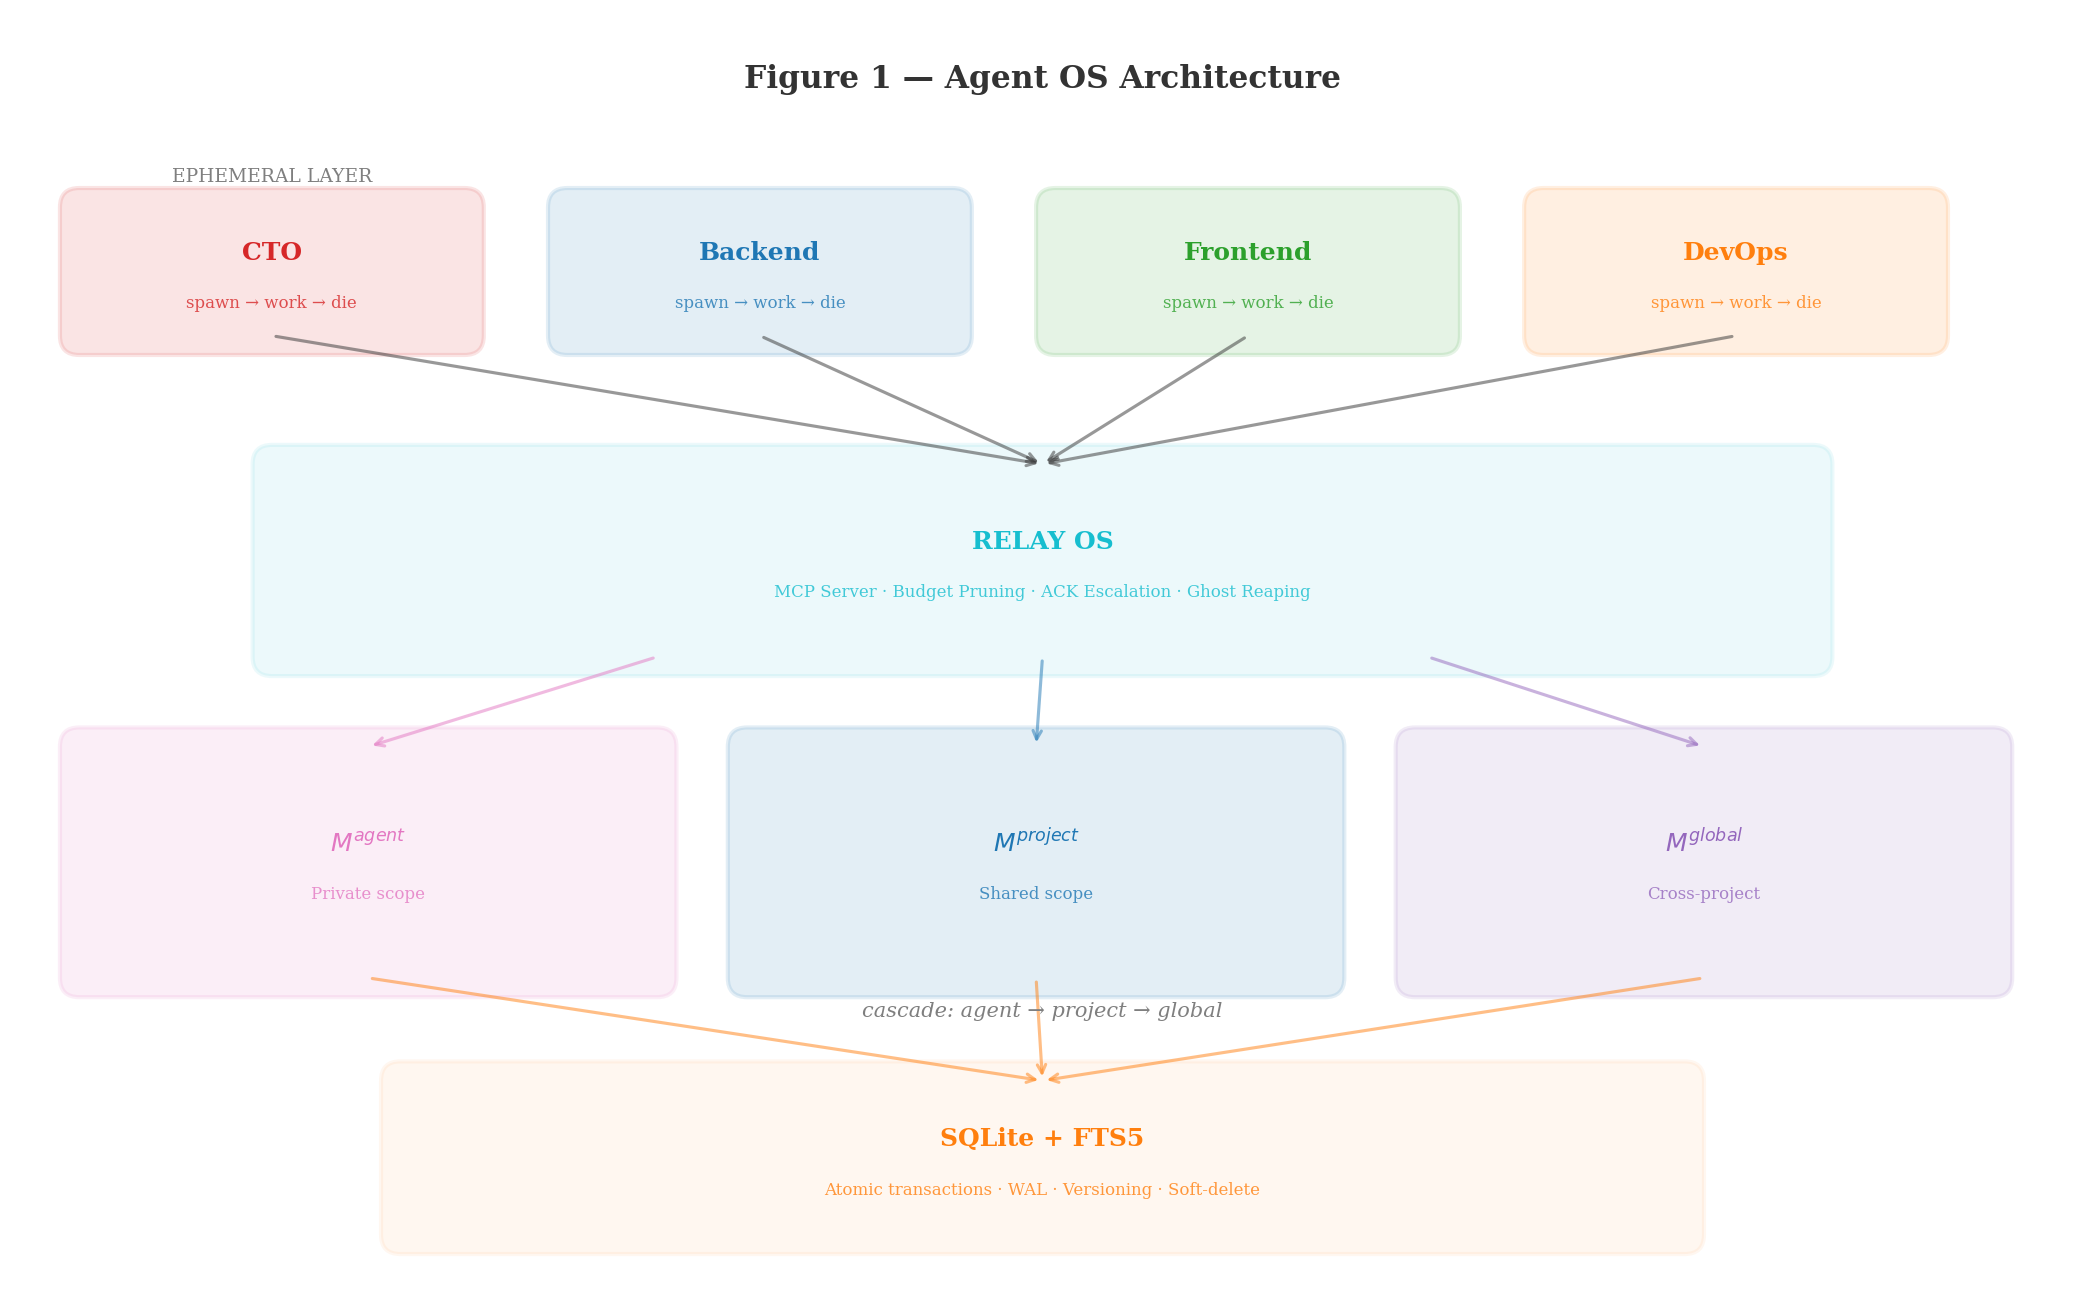

In [2]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 1 — Agent OS Architecture
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

def draw_box(ax, x, y, w, h, label, color, sublabel=None, alpha=0.12):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                         facecolor=color, alpha=alpha, edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0), label,
            ha='center', va='center', fontsize=12, fontweight='bold', color=color)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25, sublabel,
                ha='center', va='center', fontsize=8, color=color, alpha=0.8)

def draw_arrow(ax, x1, y1, x2, y2, color='#333333'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.5))

ax.text(8, 9.5, 'Figure 1 — Agent OS Architecture', ha='center', va='center',
        fontsize=15, fontweight='bold', color=C['dark'])

# Layer 1: Agents
ax.text(2, 8.7, 'EPHEMERAL LAYER', fontsize=9, color=C['gray'], ha='center')
for i, (name, col) in enumerate([('CTO', C['red']), ('Backend', C['blue']), 
                                   ('Frontend', C['green']), ('DevOps', C['orange'])]):
    draw_box(ax, 0.5 + i*3.8, 7.5, 3, 1, name, col, 'spawn → work → die')

# Layer 2: Relay
draw_box(ax, 2, 5, 12, 1.5, 'RELAY OS', C['cyan'], 
         'MCP Server · Budget Pruning · ACK Escalation · Ghost Reaping', alpha=0.08)

for i in range(4):
    draw_arrow(ax, 2 + i*3.8, 7.5, 8, 6.5)

# Layer 3: Memory Store
draw_box(ax, 0.5, 2.5, 4.5, 1.8, '$M^{agent}$', C['pink'], 'Private scope')
draw_box(ax, 5.7, 2.5, 4.5, 1.8, '$M^{project}$', C['blue'], 'Shared scope')
draw_box(ax, 10.9, 2.5, 4.5, 1.8, '$M^{global}$', C['purple'], 'Cross-project')

draw_arrow(ax, 5, 5, 2.75, 4.3, C['pink'])
draw_arrow(ax, 8, 5, 7.95, 4.3, C['blue'])
draw_arrow(ax, 11, 5, 13.15, 4.3, C['purple'])

# Layer 4: Persistence
draw_box(ax, 3, 0.5, 10, 1.2, 'SQLite + FTS5', C['orange'], 
         'Atomic transactions · WAL · Versioning · Soft-delete', alpha=0.06)

for x in [2.75, 7.95, 13.15]:
    draw_arrow(ax, x, 2.5, 8, 1.7, C['orange'])

ax.annotate('cascade: agent → project → global', xy=(8, 2.2), fontsize=10,
            color=C['gray'], ha='center', style='italic')

plt.tight_layout()
plt.show()

## 4. Ephemeral Agent Principle

### Principle

Agents are **stateless compute processes**. They carry no internal state between invocations.

$$\text{Agent} = f(M_t) \rightarrow (W, \Delta M)$$

The intelligence of the system resides entirely in $M_t$, the persistent memory store. An agent is a pure function that:

1. **Spawns** — process created by scheduler (cron) or dispatch
2. **Loads memory** — `BuildSpawnContext()` projects $M_t$ into the agent's context
3. **Computes** — executes work $W$ (code, messages, task updates)
4. **Commits** $\Delta M$ — new knowledge persisted atomically
5. **Terminates** — process dies, zero residual cost

### Contrast with Persistent Agents

| Property | Persistent Agent | Ephemeral Agent |
|----------|-----------------|----------------|
| Context window | Exhausts → loses early context | Always fresh |
| Crash recovery | Corrupted state possible | $M_t$ intact |
| Idle cost | Tokens burned (keepalive) | Zero |
| Scalability | 1 process = 1 agent | Pool of $N$ spawns |
| Knowledge | Limited to session | Cumulative $\infty$ |
| Formalism | $S_t = f(S_{t-1}, \text{input})$ (stateful) | $c : S_t \to (S_{t+1}, W)$ (functional) |

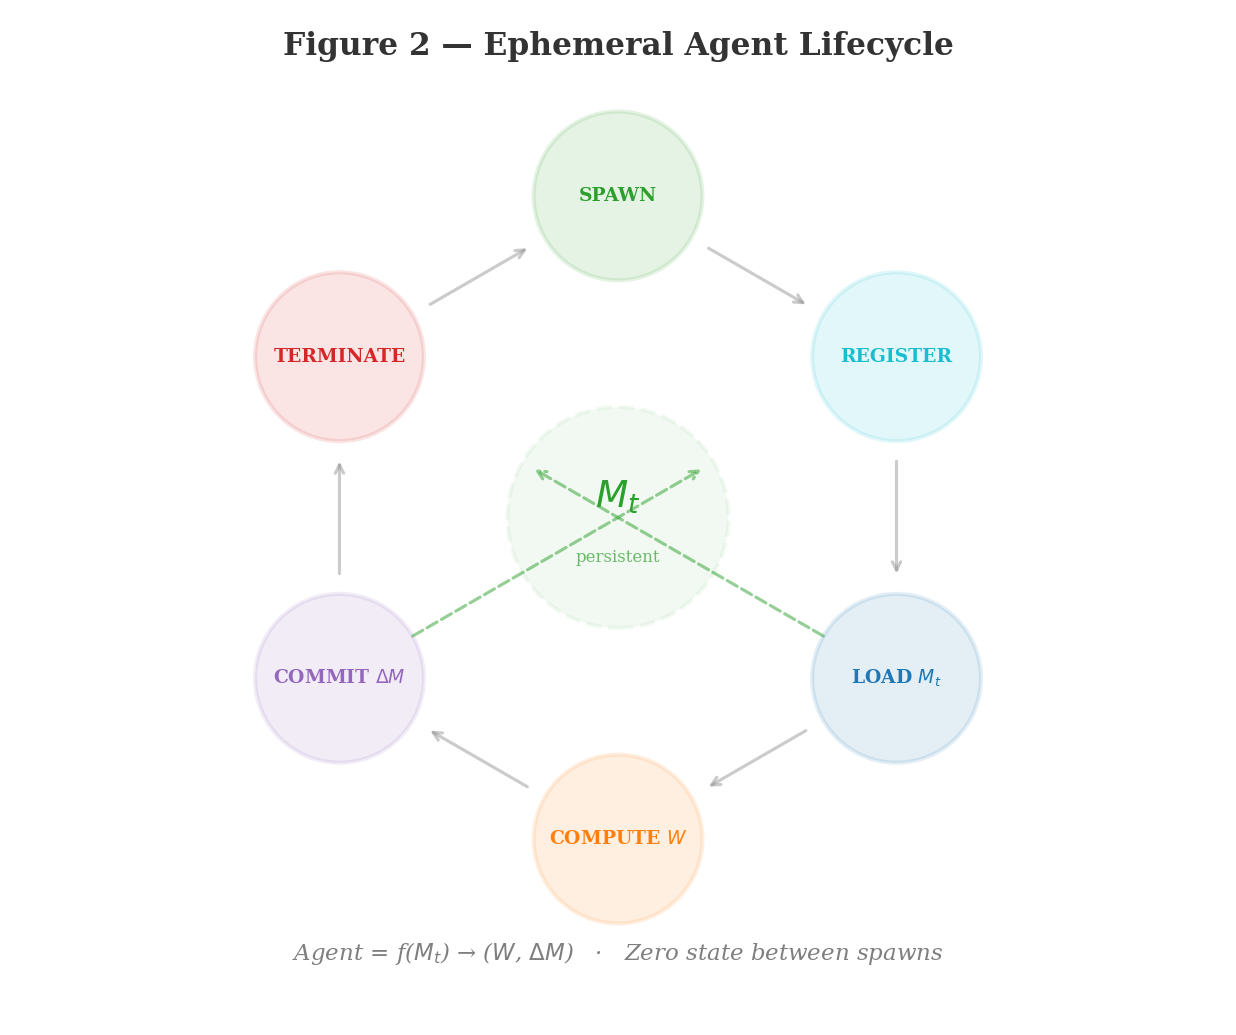

In [3]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 2 — Ephemeral Agent Lifecycle
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(-3, 3)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')

ax.text(0, 2.3, 'Figure 2 — Ephemeral Agent Lifecycle', ha='center',
        fontsize=15, fontweight='bold', color=C['dark'])

steps = [
    ('SPAWN', C['green'], 90),
    ('REGISTER', C['cyan'], 30),
    ('LOAD $M_t$', C['blue'], -30),
    ('COMPUTE $W$', C['orange'], -90),
    ('COMMIT $\\Delta M$', C['purple'], -150),
    ('TERMINATE', C['red'], 150),
]

radius = 1.6
positions = []
for label, color, angle in steps:
    rad = math.radians(angle)
    x = radius * math.cos(rad)
    y = radius * math.sin(rad)
    positions.append((x, y))
    
    circle = plt.Circle((x, y), 0.42, facecolor=color, alpha=0.12, 
                         edgecolor=color, linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=9,
            fontweight='bold', color=color)

for i in range(len(positions)):
    x1, y1 = positions[i]
    x2, y2 = positions[(i + 1) % len(positions)]
    dx, dy = x2 - x1, y2 - y1
    dist = math.sqrt(dx**2 + dy**2)
    shrink = 0.5 / dist
    ax.annotate('', xy=(x2 - dx*shrink, y2 - dy*shrink),
                xytext=(x1 + dx*shrink, y1 + dy*shrink),
                arrowprops=dict(arrowstyle='->', color=C['gray'], lw=1.5, alpha=0.4))

# Center: Memory Store
center_circle = plt.Circle((0, 0), 0.55, facecolor=C['green'], alpha=0.06,
                            edgecolor=C['green'], linewidth=2, linestyle='--')
ax.add_patch(center_circle)
ax.text(0, 0.1, '$M_t$', ha='center', va='center', fontsize=18,
        fontweight='bold', color=C['green'])
ax.text(0, -0.2, 'persistent', ha='center', va='center', fontsize=8,
        color=C['green'], alpha=0.7)

for i, label in [(2, 'read'), (4, 'write')]:
    x, y = positions[i]
    dx, dy = -x, -y
    dist = math.sqrt(dx**2 + dy**2)
    ax.annotate('', xy=(dx*0.5/dist, dy*0.5/dist),
                xytext=(x + dx*0.4/dist, y + dy*0.4/dist),
                arrowprops=dict(arrowstyle='->', color=C['green'], lw=1.5, 
                               linestyle='--', alpha=0.5))

ax.text(0, -2.2, 'Agent = f($M_t$) → ($W$, $\\Delta M$)   ·   Zero state between spawns',
        ha='center', fontsize=11, color=C['gray'], style='italic')

plt.tight_layout()
plt.show()

## 5. Atomic Memory Commit

### Definition 4 — Cycle Transition

$$c : S_t \rightarrow (S_{t+1}, W)$$

Where $W$ = work produced. The state transition decomposes:

- $M_{t+1} = \text{compact}(M_t \cup \Delta M_{\text{valid}})$ — memory updated (filtered + compacted)
- $\Omega_{t+1}' = \Omega_t \cup \Delta \Omega$ — messages emitted to other agents
- $T_{t+1}$ — tasks updated (claimed, completed, blocked)

### Definition 5 — Atomicity Property

$$M_{t+1} = \begin{cases} \text{compact}(M_t \cup \Delta M_{\text{valid}}) & \text{if cycle succeeds (exit 0)} \\ M_t & \text{if cycle crashes} \end{cases}$$

No intermediate corrupted state. Transaction commit or rollback.

### Definition 6 — Memory Validation Filter

$$\Delta M_{\text{valid}} = \text{filter}(\Delta M, M_t)$$

The filter enforces:
- **Conflict detection**: two agents writing same key → both preserved until explicit resolution
- **Layer hierarchy**: `constraints > behavior > context` — a `behavior` write cannot override `constraints`
- **Scope isolation**: `agent` (private) / `project` (shared) / `global` (cross-project)
- **Deduplication**: same key+value → timestamp update only, no new version

### Definition 7 — Memory Compaction

$$|M_{\text{boot}}| \leq B_{\max}$$

The raw memory grows monotonically, but the **projected view** at boot is bounded by a byte budget.

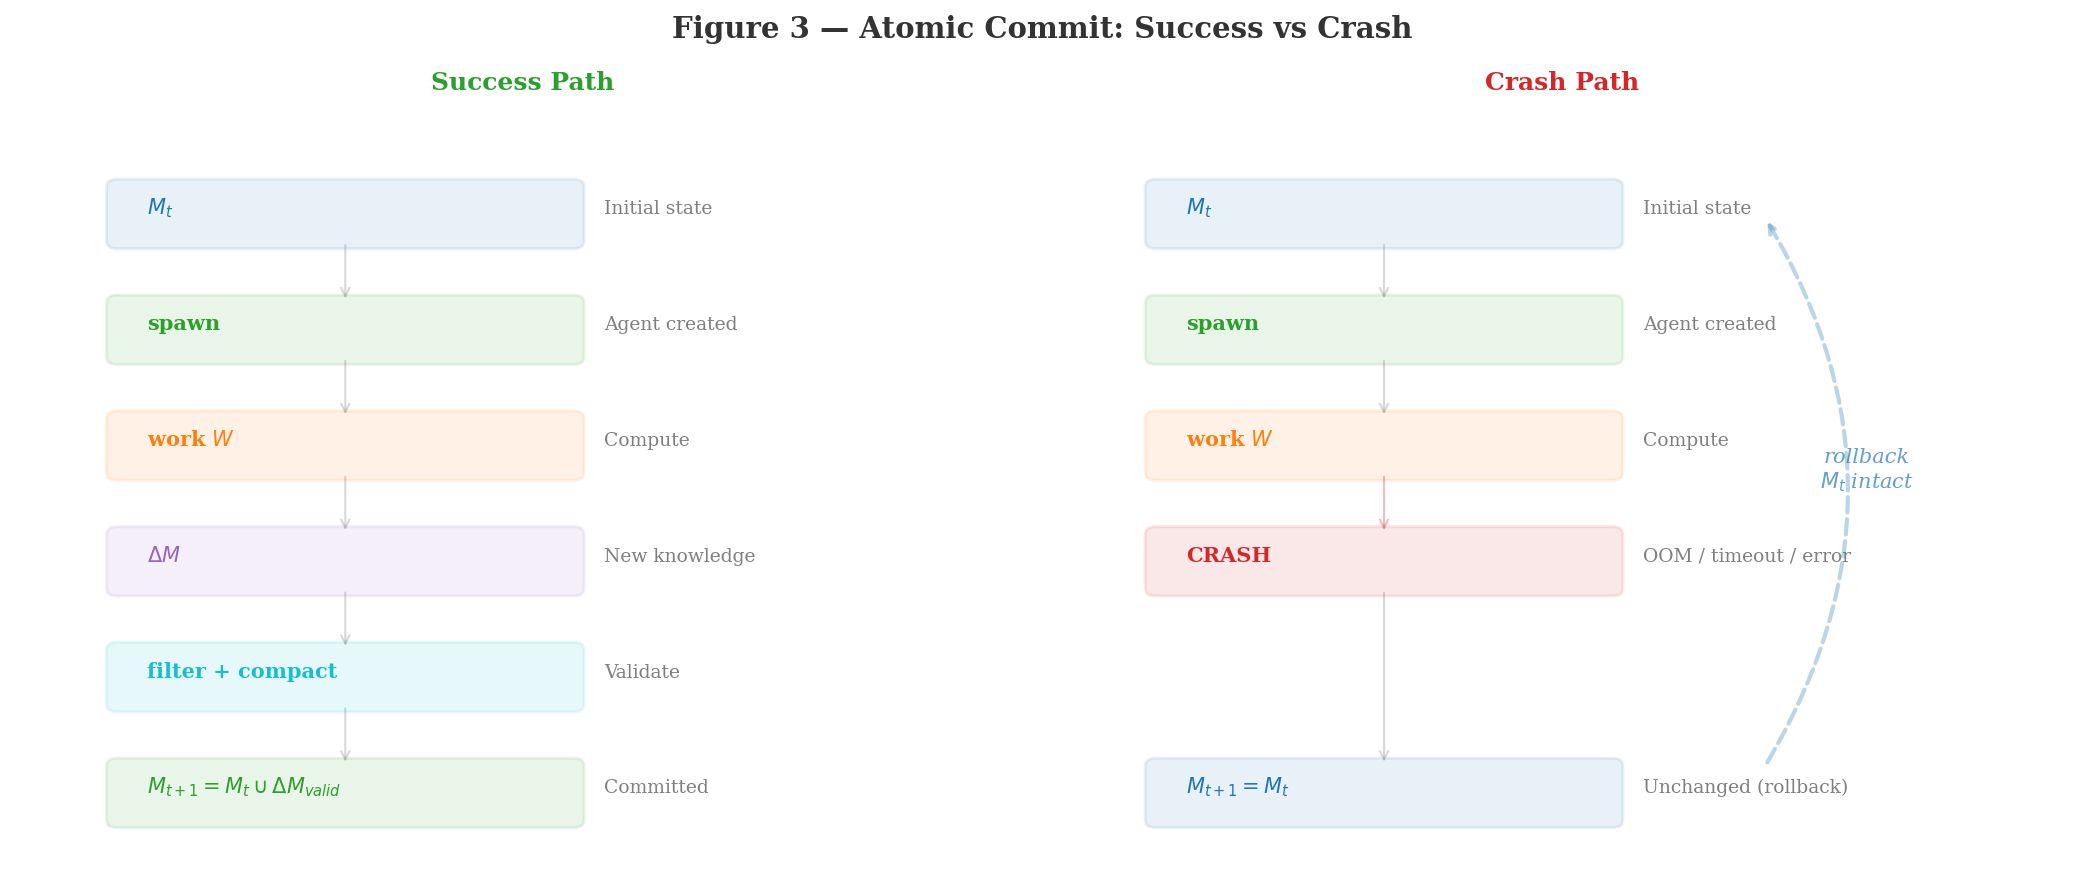

In [4]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 3 — Atomic Commit vs Crash
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 3 — Atomic Commit: Success vs Crash', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

# === LEFT: Success ===
ax = axes[0]
ax.set_title('Success Path', fontsize=12, color=C['green'], fontweight='bold')
steps = [
    (1, 8.5, '$M_t$', C['blue'], 'Initial state'),
    (1, 7.0, 'spawn', C['green'], 'Agent created'),
    (1, 5.5, 'work $W$', C['orange'], 'Compute'),
    (1, 4.0, '$\\Delta M$', C['purple'], 'New knowledge'),
    (1, 2.5, 'filter + compact', C['cyan'], 'Validate'),
    (1, 1.0, '$M_{t+1} = M_t \\cup \\Delta M_{valid}$', C['green'], 'Committed'),
]
for x, y, label, color, desc in steps:
    box = FancyBboxPatch((x, y-0.3), 4.5, 0.7, boxstyle="round,pad=0.1",
                         facecolor=color, alpha=0.1, edgecolor=color, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x+0.3, y+0.05, label, fontsize=10, fontweight='bold', color=color)
    ax.text(x+4.8, y+0.05, desc, fontsize=9, color=C['gray'])
for i in range(len(steps)-1):
    ax.annotate('', xy=(3.25, steps[i+1][1]+0.4), xytext=(3.25, steps[i][1]-0.3),
                arrowprops=dict(arrowstyle='->', color=C['gray'], lw=1, alpha=0.3))

# === RIGHT: Crash ===
ax = axes[1]
ax.set_title('Crash Path', fontsize=12, color=C['red'], fontweight='bold')
steps = [
    (1, 8.5, '$M_t$', C['blue'], 'Initial state'),
    (1, 7.0, 'spawn', C['green'], 'Agent created'),
    (1, 5.5, 'work $W$', C['orange'], 'Compute'),
    (1, 4.0, 'CRASH', C['red'], 'OOM / timeout / error'),
    (1, 1.0, '$M_{t+1} = M_t$', C['blue'], 'Unchanged (rollback)'),
]
for x, y, label, color, desc in steps:
    box = FancyBboxPatch((x, y-0.3), 4.5, 0.7, boxstyle="round,pad=0.1",
                         facecolor=color, alpha=0.1, edgecolor=color, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x+0.3, y+0.05, label, fontsize=10, fontweight='bold', color=color)
    ax.text(x+4.8, y+0.05, desc, fontsize=9, color=C['gray'])
for i in range(len(steps)-1):
    ax.annotate('', xy=(3.25, steps[i+1][1]+0.4), xytext=(3.25, steps[i][1]-0.3),
                arrowprops=dict(arrowstyle='->', color=C['red'] if i==2 else C['gray'], lw=1, alpha=0.3))

# Rollback arrow
ax.annotate('', xy=(7, 8.5), xytext=(7, 1.4),
            arrowprops=dict(arrowstyle='->', color=C['blue'], lw=2,
                           linestyle='--', alpha=0.3, connectionstyle='arc3,rad=0.3'))
ax.text(8, 5, 'rollback\n$M_t$ intact', fontsize=10, color=C['blue'],
        ha='center', alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

## 6. Knowledge Evolution

### Spawn Chain Inheritance

For two successive spawns $s_1$ and $s_2$ of the same profile:

$$M(s_2) \supseteq M(s_1)$$

Agent $s_2$ **knows everything** $s_1$ learned. This is not shared memory at runtime — it is **boot-time inheritance** via `BuildSpawnContext()`.

### Inter-Agent Memory Elimination

An agent can supersede another agent's knowledge:

$$\text{set\_memory}(\text{key}, v_{\text{new}}, \text{scope:project}, \text{upsert:true})$$

Archives the old version (field `supersedes`), increments `version`. Complete traceability, never hard-delete.

$$v_1 \xrightarrow{\text{supersedes}} v_2 \xrightarrow{\text{supersedes}} v_3$$

### Self-Learning Correction

A Backend agent can correct a Frontend agent's project memory if it discovers it is inaccurate. The `supersedes` chain preserves full provenance.

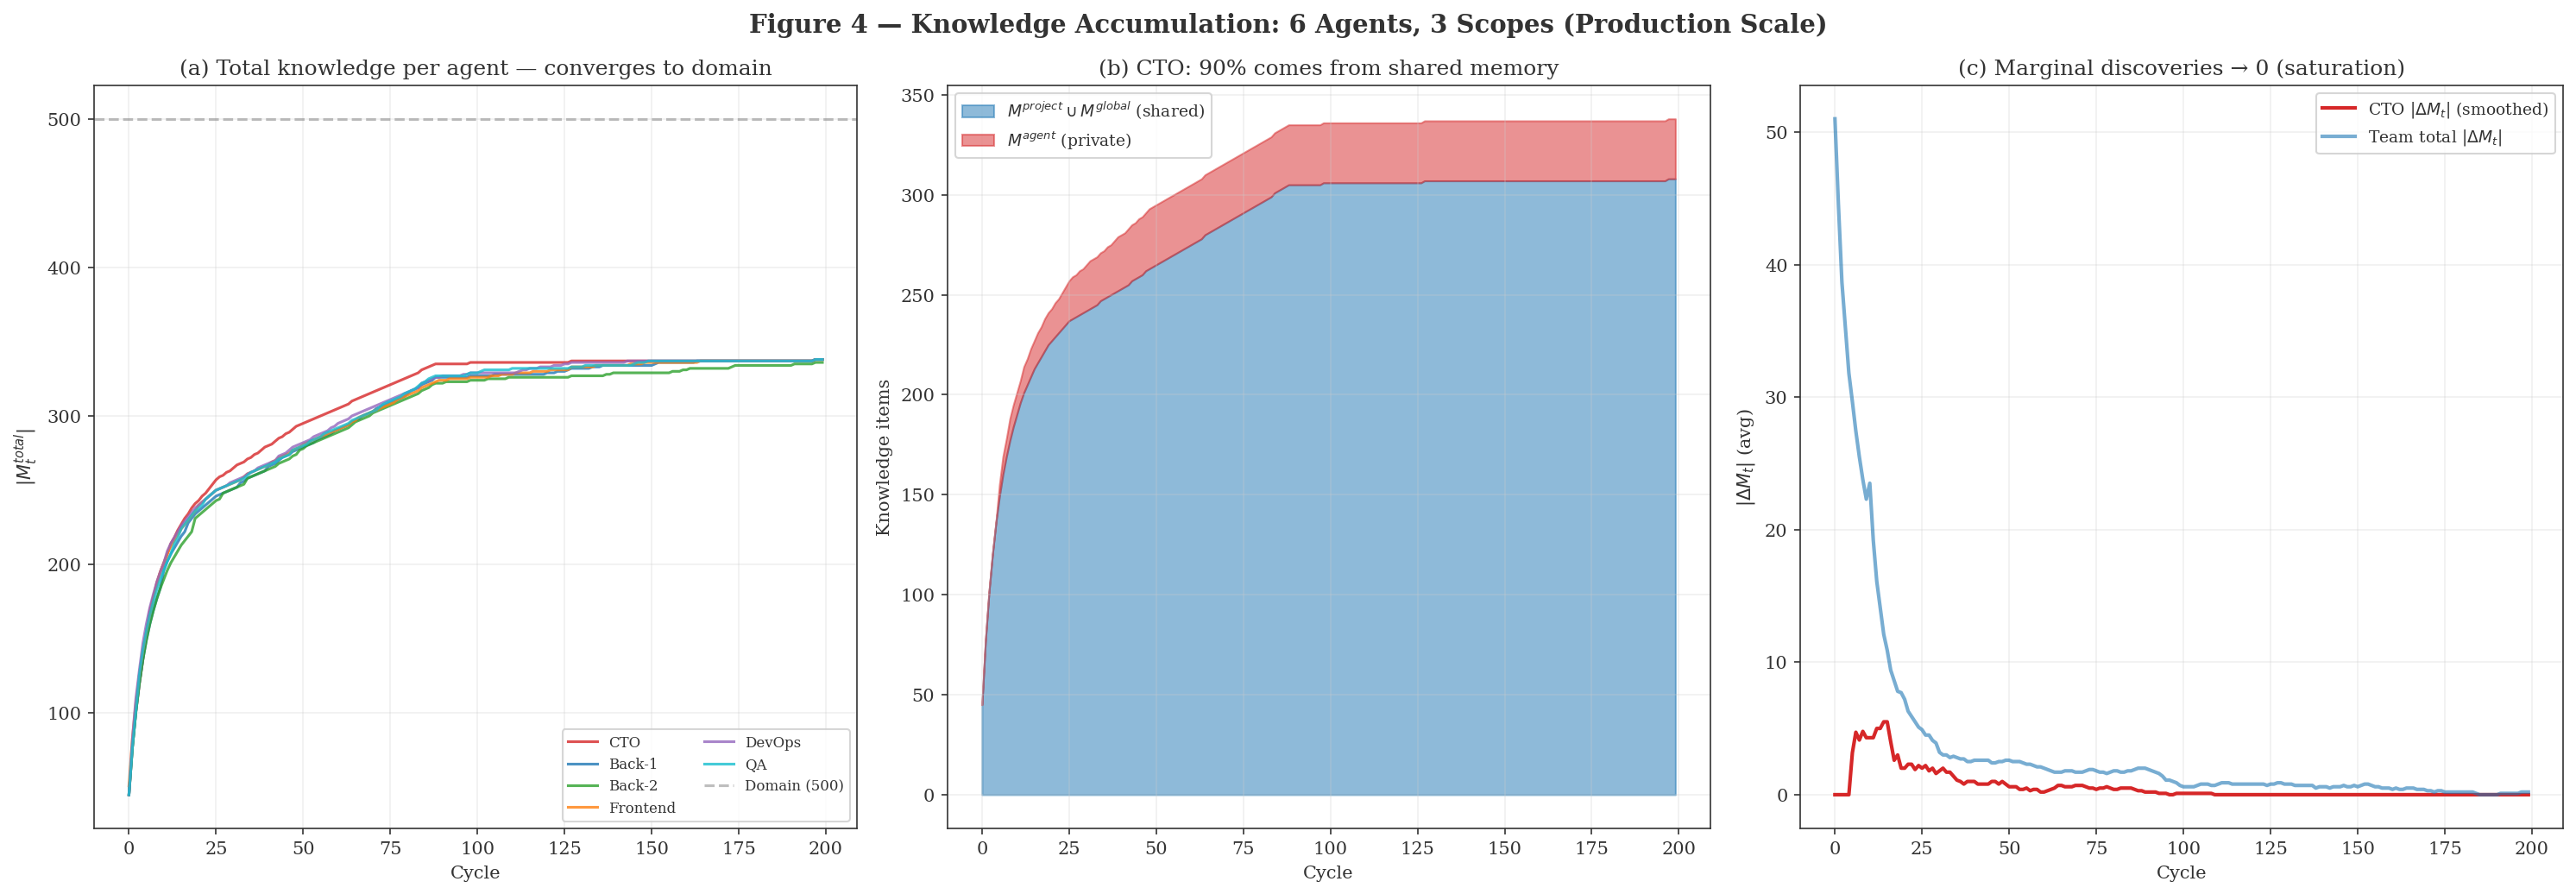

After 200 cycles:
  CTO: 338 items (30 private, 308 shared)
  Back-1: 338 items (30 private, 308 shared)
  Back-2: 336 items (28 private, 308 shared)
  Frontend: 338 items (30 private, 308 shared)
  DevOps: 338 items (30 private, 308 shared)
  QA: 338 items (30 private, 308 shared)


In [5]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 4 — Knowledge Accumulation: 6 Agents, 3 Scopes (Production Scale)
# ═══════════════════════════════════════════════════════════════

def simulate_knowledge_production(domain_size=500, n_cycles=200, seed=42):
    """Simulate 6 agents with realistic learning rates and shared project memory."""
    rng = random.Random(seed)
    
    # Domain split: 60% project-shared, 30% agent-specific, 10% global
    domain_project = set(range(0, 300))
    domain_agents = [set(range(300 + i*30, 300 + (i+1)*30)) for i in range(6)]
    domain_global = set(range(480, 500))
    
    agents = ['CTO', 'Back-1', 'Back-2', 'Frontend', 'DevOps', 'QA']
    M_project = set()
    M_private = [set() for _ in range(6)]
    M_global = set()
    
    # CTO spawns more (heartbeat), workers less
    spawn_weights = [3, 1, 1, 1, 1, 1]  # relative frequency
    
    history = {n: {'total': [], 'private': [], 'shared': [], 'delta': []} for n in agents}
    
    for cycle in range(n_cycles):
        # Weighted agent selection (CTO 3x more frequent)
        idx = rng.choices(range(6), weights=spawn_weights, k=1)[0]
        delta = 0
        
        # Project knowledge (shared — this is the key differentiator)
        unknown_proj = domain_project - M_project
        if unknown_proj:
            # Learning rate decreases as domain fills (realistic convergence)
            p = 0.15 * (len(unknown_proj) / len(domain_project))
            n_new = max(1, int(len(unknown_proj) * p))
            M_project |= set(rng.sample(list(unknown_proj), min(n_new, len(unknown_proj))))
            delta += n_new
        
        # Private knowledge (agent-specific)
        unknown_priv = domain_agents[idx] - M_private[idx]
        if unknown_priv:
            p = 0.2 * (len(unknown_priv) / len(domain_agents[idx]))
            n_new = max(1, int(len(unknown_priv) * p))
            M_private[idx] |= set(rng.sample(list(unknown_priv), min(n_new, len(unknown_priv))))
            delta += n_new
        
        # Global (rare cross-project insights)
        unknown_global = domain_global - M_global
        if unknown_global and rng.random() < 0.05:
            M_global.add(rng.choice(list(unknown_global)))
            delta += 1
        
        for i, n in enumerate(agents):
            total = len(M_private[i]) + len(M_project) + len(M_global)
            history[n]['total'].append(total)
            history[n]['private'].append(len(M_private[i]))
            history[n]['shared'].append(len(M_project) + len(M_global))
        history[agents[idx]]['delta'].append(delta)
        for other_idx, other in enumerate(agents):
            if other_idx != idx:
                history[other]['delta'].append(0)
    
    return history, agents, domain_size

hist, agents, dsize = simulate_knowledge_production()
colors = [C['red'], C['blue'], C['green'], C['orange'], C['purple'], C['cyan']]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 4 — Knowledge Accumulation: 6 Agents, 3 Scopes (Production Scale)', 
             fontsize=14, fontweight='bold', color=C['dark'])

# 4a. Total knowledge per agent — convergence
ax = axes[0]
for name, color in zip(agents, colors):
    ax.plot(hist[name]['total'], color=color, linewidth=1.5, label=name, alpha=0.8)
ax.axhline(y=dsize, color=C['gray'], linestyle='--', alpha=0.5, label=f'Domain ({dsize})')
ax.set_xlabel('Cycle'); ax.set_ylabel('$|M_t^{total}|$')
ax.set_title('(a) Total knowledge per agent — converges to domain')
ax.legend(fontsize=8, ncol=2)

# 4b. Shared vs Private (stacked, CTO perspective)
ax = axes[1]
shared = hist['CTO']['shared']
private = hist['CTO']['private']
cycles = range(len(shared))
ax.fill_between(cycles, shared, alpha=0.5, color=C['blue'], label='$M^{project} \\cup M^{global}$ (shared)')
ax.fill_between(cycles, shared, [s+p for s,p in zip(shared, private)],
                alpha=0.5, color=C['red'], label='$M^{agent}$ (private)')
ax.set_xlabel('Cycle'); ax.set_ylabel('Knowledge items')
ax.set_title('(b) CTO: 90% comes from shared memory')
ax.legend(fontsize=9)

# 4c. Marginal learning rate — dramatic decrease
ax = axes[2]
# Smooth delta with rolling average
window = 10
cto_deltas = hist['CTO']['delta']
smoothed = [sum(cto_deltas[max(0,i-window):i+1])/(min(i+1,window)) for i in range(len(cto_deltas))]
ax.plot(smoothed, color=C['red'], linewidth=2, label='CTO $|\\Delta M_t|$ (smoothed)')
# Show team aggregate
all_deltas = [sum(hist[a]['delta'][i] for a in agents) for i in range(len(cto_deltas))]
smoothed_all = [sum(all_deltas[max(0,i-window):i+1])/(min(i+1,window)) for i in range(len(all_deltas))]
ax.plot(smoothed_all, color=C['blue'], linewidth=2, alpha=0.6, label='Team total $|\\Delta M_t|$')
ax.set_xlabel('Cycle'); ax.set_ylabel('$|\\Delta M_t|$ (avg)')
ax.set_title('(c) Marginal discoveries → 0 (saturation)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"After {len(hist['CTO']['total'])} cycles:")
for a in agents:
    print(f"  {a}: {hist[a]['total'][-1]} items ({hist[a]['private'][-1]} private, {hist[a]['shared'][-1]} shared)")

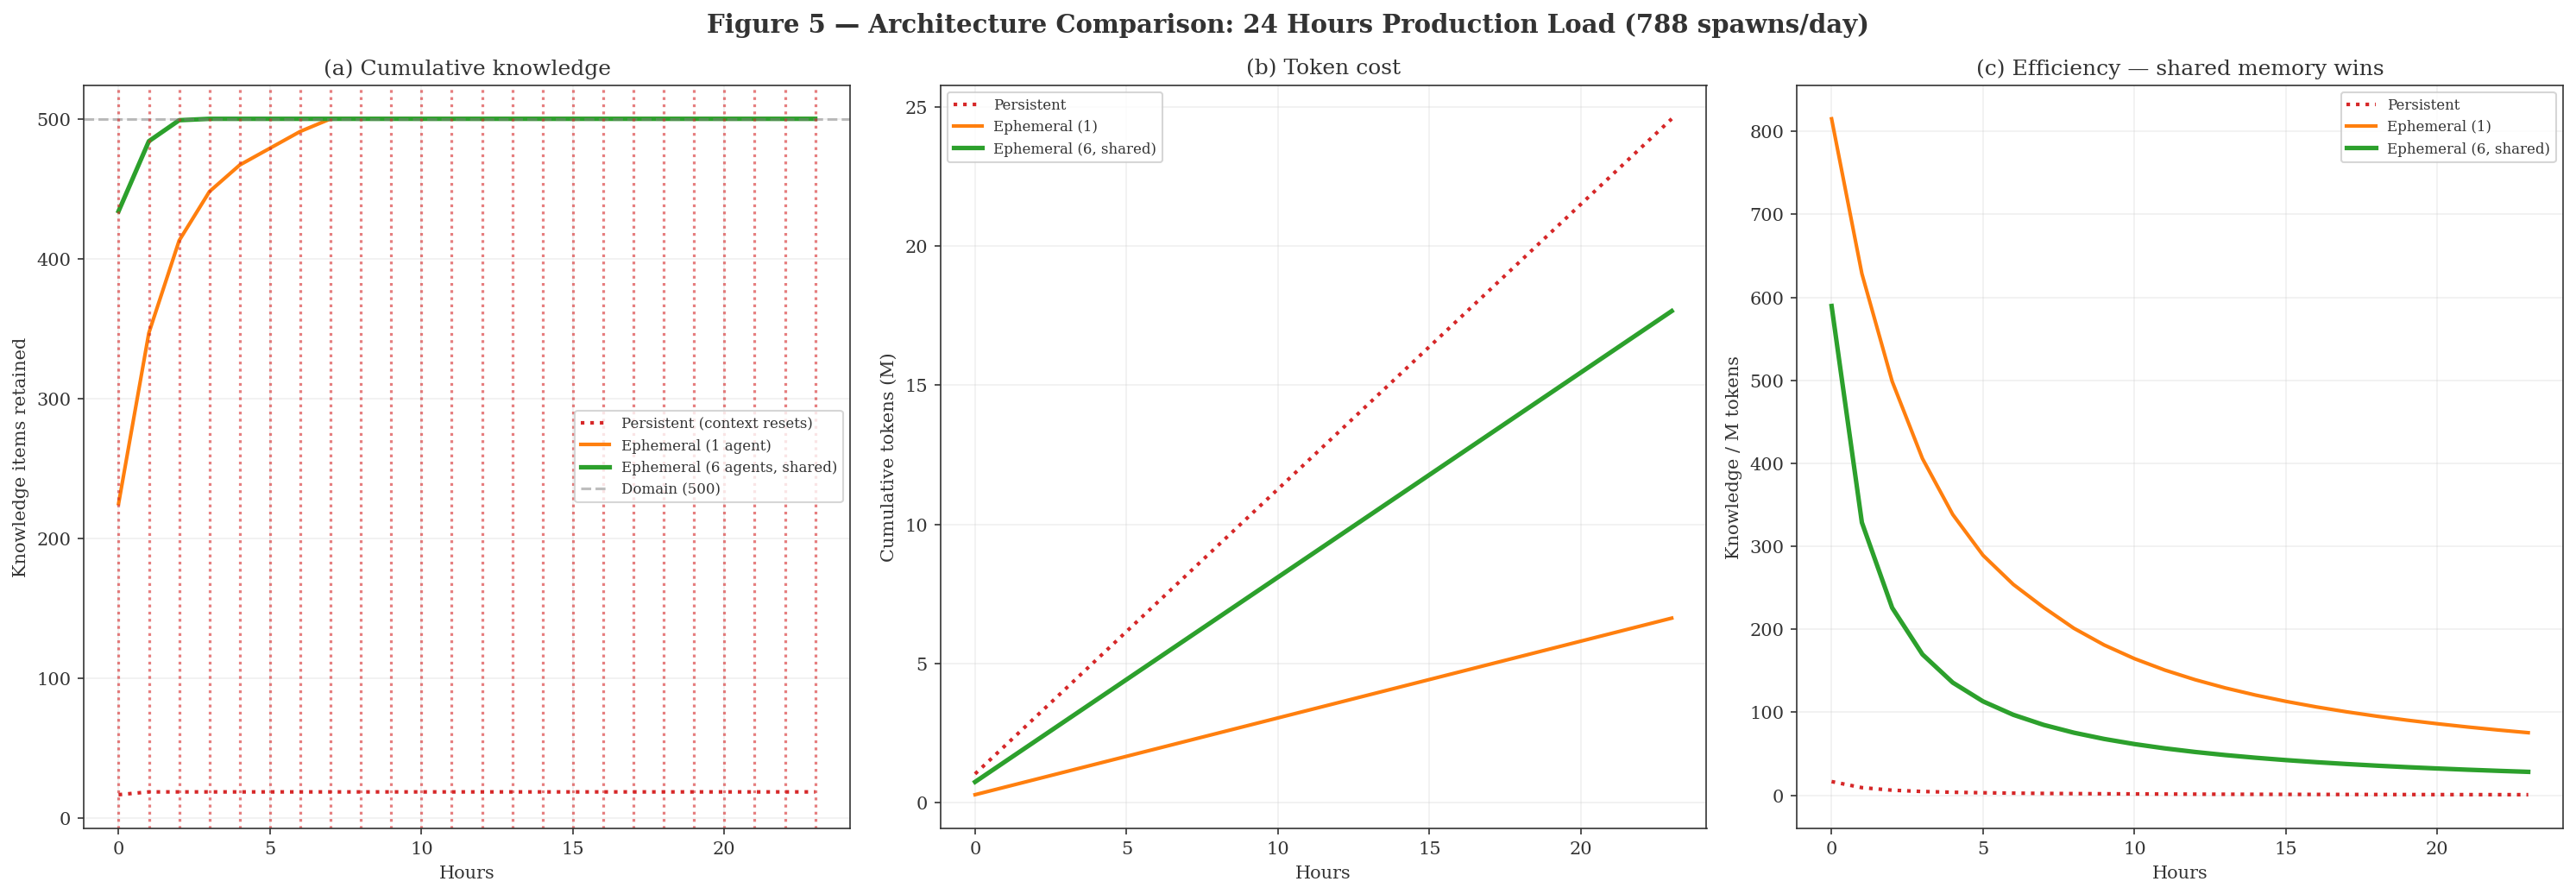

After 24h:
  Persistent: 19 items, 24.6M tokens, 96 context resets
  Ephemeral (1): 500 items, 6.6M tokens
  Ephemeral (6): 500 items, 17.7M tokens
  Multi-agent advantage: 26.3x knowledge, 28% cost reduction vs persistent


In [6]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 5 — Persistent vs Ephemeral: 24h Production Comparison
# ═══════════════════════════════════════════════════════════════

def compare_architectures_production(n_hours=24):
    """Realistic comparison based on production relay OS data."""
    rng = random.Random(42)
    domain = set(range(500))  # 500 knowledge items (realistic project)
    
    # --- Architecture 1: Persistent (long-running) agent ---
    # Context window ~200K, but effective context degrades after ~80K
    # Must periodically summarize/reset, losing nuance
    p_knowledge, p_cost, p_context = [], [], []
    M_persistent = set()
    ctx_window, total_cost = 0, 0
    resets = []
    for h in range(n_hours):
        spawns_this_hour = 12  # CTO heartbeat = 12/hour
        for _ in range(spawns_this_hour):
            ctx_window += 67_000  # naive boot each time
            total_cost += 67_000
            # After 80K context, quality degrades — hallucinations increase
            quality = max(0.2, 1.0 - (ctx_window / 200_000))
            if ctx_window > 180_000:
                # Force reset: lose 40% of learned context
                ctx_window = 30_000
                lost = set(rng.sample(list(M_persistent), max(0, int(len(M_persistent) * 0.4))))
                M_persistent -= lost
                total_cost += 10_000  # summarization cost
                resets.append(h)
            # Learning degraded by context quality
            unknown = domain - M_persistent
            if unknown:
                n_learn = max(0, int(len(unknown) * 0.03 * quality))
                if n_learn > 0:
                    M_persistent |= set(rng.sample(list(unknown), min(n_learn, len(unknown))))
            total_cost += 15_000  # work
        p_knowledge.append(len(M_persistent))
        p_cost.append(total_cost)
        p_context.append(ctx_window)
    
    # --- Architecture 2: Ephemeral single agent (relay OS, 1 agent) ---
    e_knowledge, e_cost = [], []
    M_ephemeral = set()
    total_cost = 0
    for h in range(n_hours):
        for _ in range(12):
            boot = 8_000  # build_prompt optimized
            total_cost += boot
            # Always fresh context — consistent quality
            unknown = domain - M_ephemeral
            if unknown:
                n_learn = max(1, int(len(unknown) * 0.05))
                M_ephemeral |= set(rng.sample(list(unknown), min(n_learn, len(unknown))))
            total_cost += 15_000
        e_knowledge.append(len(M_ephemeral))
        e_cost.append(total_cost)
    
    # --- Architecture 3: Ephemeral multi-agent (relay OS, 6 agents) ---
    m_knowledge, m_cost = [], []
    M_shared = set()
    M_private = [set() for _ in range(6)]
    total_cost = 0
    agent_names = ['CTO', 'Back-1', 'Back-2', 'Front', 'DevOps', 'QA']
    spawns = [12, 4, 4, 4, 4, 4]  # CTO=12/h, workers=4/h
    for h in range(n_hours):
        for agent_idx, n_spawns in enumerate(spawns):
            for _ in range(n_spawns):
                visible = M_shared | M_private[agent_idx]
                boot = 8_000  # build_prompt
                total_cost += boot
                unknown = domain - visible
                if unknown:
                    n_learn = max(1, int(len(unknown) * 0.06))
                    delta = set(rng.sample(list(unknown), min(n_learn, len(unknown))))
                    # 70% goes to shared project memory, 30% private
                    dl = list(delta); split = int(len(dl) * 0.7)
                    M_shared |= set(dl[:split])
                    M_private[agent_idx] |= set(dl[split:])
                total_cost += 15_000
        all_k = M_shared.copy()
        for mp in M_private: all_k |= mp
        m_knowledge.append(len(all_k))
        m_cost.append(total_cost)
    
    return (p_knowledge, p_cost, resets,
            e_knowledge, e_cost,
            m_knowledge, m_cost, domain)

pk, pc, resets, ek, ec, mk, mc, domain = compare_architectures_production()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 5 — Architecture Comparison: 24 Hours Production Load (788 spawns/day)', 
             fontsize=14, fontweight='bold', color=C['dark'])

hours = list(range(24))

# 5a. Knowledge retention
ax = axes[0]
ax.plot(hours, pk, color=C['red'], linewidth=2, linestyle=':', label='Persistent (context resets)')
ax.plot(hours, ek, color=C['orange'], linewidth=2, label='Ephemeral (1 agent)')
ax.plot(hours, mk, color=C['green'], linewidth=2.5, label='Ephemeral (6 agents, shared)')
ax.axhline(y=len(domain), color=C['gray'], linestyle='--', alpha=0.5, label=f'Domain ({len(domain)})')
for r in resets:
    ax.axvline(x=r, color=C['red'], alpha=0.2, linestyle=':')
ax.set_xlabel('Hours'); ax.set_ylabel('Knowledge items retained')
ax.set_title('(a) Cumulative knowledge'); ax.legend(fontsize=8)

# 5b. Token cost
ax = axes[1]
ax.plot(hours, [c/1e6 for c in pc], color=C['red'], linewidth=2, linestyle=':', label='Persistent')
ax.plot(hours, [c/1e6 for c in ec], color=C['orange'], linewidth=2, label='Ephemeral (1)')
ax.plot(hours, [c/1e6 for c in mc], color=C['green'], linewidth=2.5, label='Ephemeral (6, shared)')
ax.set_xlabel('Hours'); ax.set_ylabel('Cumulative tokens (M)')
ax.set_title('(b) Token cost'); ax.legend(fontsize=8)

# 5c. Efficiency (knowledge per M tokens)
ax = axes[2]
p_eff = [k/(c/1e6) if c > 0 else 0 for k, c in zip(pk, pc)]
e_eff = [k/(c/1e6) if c > 0 else 0 for k, c in zip(ek, ec)]
m_eff = [k/(c/1e6) if c > 0 else 0 for k, c in zip(mk, mc)]
ax.plot(hours, p_eff, color=C['red'], linewidth=2, linestyle=':', label='Persistent')
ax.plot(hours, e_eff, color=C['orange'], linewidth=2, label='Ephemeral (1)')
ax.plot(hours, m_eff, color=C['green'], linewidth=2.5, label='Ephemeral (6, shared)')
ax.set_xlabel('Hours'); ax.set_ylabel('Knowledge / M tokens')
ax.set_title('(c) Efficiency — shared memory wins', color=C['dark']); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"After 24h:")
print(f"  Persistent: {pk[-1]} items, {pc[-1]/1e6:.1f}M tokens, {len(resets)} context resets")
print(f"  Ephemeral (1): {ek[-1]} items, {ec[-1]/1e6:.1f}M tokens")
print(f"  Ephemeral (6): {mk[-1]} items, {mc[-1]/1e6:.1f}M tokens")
print(f"  Multi-agent advantage: {mk[-1]/max(pk[-1],1):.1f}x knowledge, {(1-mc[-1]/pc[-1])*100:.0f}% cost reduction vs persistent")

## 7. Convergence Conjecture

### Conjecture: Knowledge Saturation Hypothesis

$$\lim_{n \to \infty} |\Delta M_{\text{valid},n}| \to 0 \quad \text{(finite domain, active filter)}$$

**This is not a theorem.** It is an empirical hypothesis that holds under three conditions:

1. The knowledge domain is finite (bounded by the project)
2. The filter $\text{filter}(\Delta M, M_t)$ eliminates duplicates and contradictions
3. The agent learns effectively (no hallucination loops)

In practice, LLMs produce noise (repetitions, trivialities, hallucinations). The observed convergence is due to the **filter + compaction**, not an intrinsic property of learning.

### Corollary: Marginal Cost Decrease

$$C_t = \underbrace{C_{\text{boot}}}_{\text{fixed}} + \underbrace{C_{\text{context}}(|M_t^{\text{visible}}|)}_{\text{bounded by } B_{\max}} + \underbrace{C_{\text{work}}}_{\text{constant}} + \underbrace{C_{\text{learn}}(|\Delta M_t|)}_{\text{decreasing}}$$

As $|\Delta M_t| \to 0$, the cost converges to $C_{\text{boot}} + C_{\text{context}} + C_{\text{work}}$ — the learning overhead vanishes.

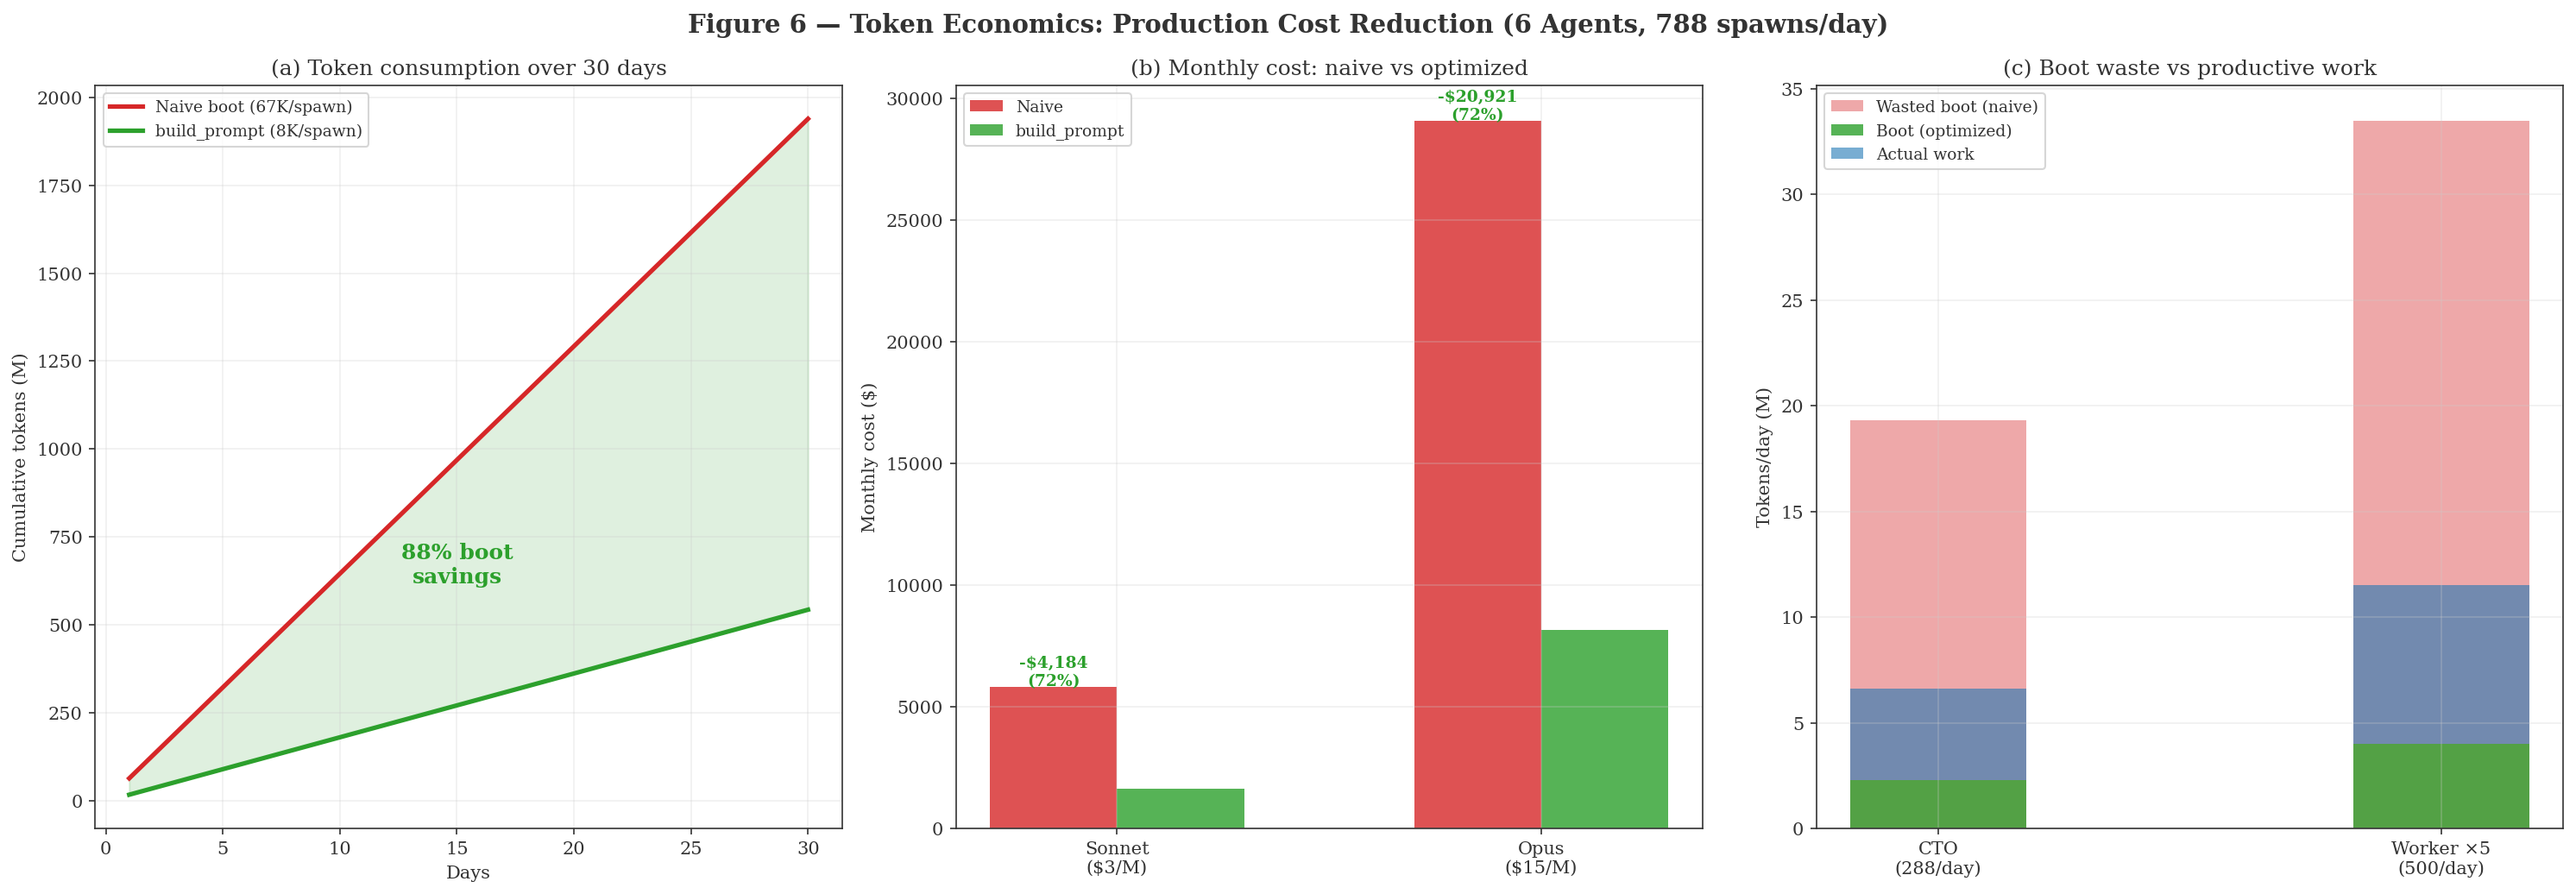

Boot tokens/day: 52.8M → 6.3M (88% reduction)
Total tokens/day: 64.6M → 18.1M (72% reduction)
Sonnet: $5,815/mo → $1,631/mo
Opus:   $29,077/mo → $8,156/mo


In [7]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 6 — Token Economics: Boot Cost Reduction (Production Data)
# ═══════════════════════════════════════════════════════════════

# Real production parameters from relay OS deployment
CTO_SPAWNS_PER_DAY = 288        # heartbeat every 5min
WORKER_SPAWNS_PER_DAY = 100     # per worker
N_WORKERS = 5
BOOT_NAIVE = 67_000             # tokens per spawn without build_prompt
BOOT_OPTIMIZED = 8_000          # tokens per spawn with build_prompt
WORK_TOKENS = 15_000            # avg work tokens per spawn
COST_PER_M_SONNET = 3.0         # $/1M input tokens (Claude Sonnet)
COST_PER_M_OPUS = 15.0          # $/1M input tokens (Claude Opus)

# Simulate 30 days of operation
days = list(range(1, 31))

# --- Without build_prompt (naive) ---
naive_boot_day = (CTO_SPAWNS_PER_DAY + N_WORKERS * WORKER_SPAWNS_PER_DAY) * BOOT_NAIVE
naive_work_day = (CTO_SPAWNS_PER_DAY + N_WORKERS * WORKER_SPAWNS_PER_DAY) * WORK_TOKENS
naive_total_day = naive_boot_day + naive_work_day

# --- With build_prompt (optimized) ---
opt_boot_day = (CTO_SPAWNS_PER_DAY + N_WORKERS * WORKER_SPAWNS_PER_DAY) * BOOT_OPTIMIZED
opt_work_day = naive_work_day  # work tokens same
opt_total_day = opt_boot_day + opt_work_day

naive_cumul = [naive_total_day * d / 1e6 for d in days]
opt_cumul = [opt_total_day * d / 1e6 for d in days]
savings_cumul = [(naive_total_day - opt_total_day) * d / 1e6 for d in days]

# Cost curves
naive_cost_sonnet = [naive_total_day * d * COST_PER_M_SONNET / 1e6 for d in days]
opt_cost_sonnet = [opt_total_day * d * COST_PER_M_SONNET / 1e6 for d in days]
naive_cost_opus = [naive_total_day * d * COST_PER_M_OPUS / 1e6 for d in days]
opt_cost_opus = [opt_total_day * d * COST_PER_M_OPUS / 1e6 for d in days]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 6 — Token Economics: Production Cost Reduction (6 Agents, 788 spawns/day)', 
             fontsize=14, fontweight='bold', color=C['dark'])

# 6a. Token consumption
ax = axes[0]
ax.plot(days, naive_cumul, color=C['red'], linewidth=2.5, label=f'Naive boot ({BOOT_NAIVE//1000}K/spawn)')
ax.plot(days, opt_cumul, color=C['green'], linewidth=2.5, label=f'build_prompt ({BOOT_OPTIMIZED//1000}K/spawn)')
ax.fill_between(days, opt_cumul, naive_cumul, alpha=0.15, color=C['green'])
ax.set_xlabel('Days'); ax.set_ylabel('Cumulative tokens (M)')
ax.set_title('(a) Token consumption over 30 days')
ax.legend(fontsize=9)
ax.text(15, (naive_cumul[14] + opt_cumul[14])/2, f'88% boot\nsavings', 
        ha='center', fontsize=12, fontweight='bold', color=C['green'])

# 6b. Monthly cost comparison (Sonnet vs Opus)
ax = axes[1]
categories = ['Sonnet\n($3/M)', 'Opus\n($15/M)']
naive_monthly = [naive_total_day * 30 * COST_PER_M_SONNET / 1e6,
                 naive_total_day * 30 * COST_PER_M_OPUS / 1e6]
opt_monthly = [opt_total_day * 30 * COST_PER_M_SONNET / 1e6,
               opt_total_day * 30 * COST_PER_M_OPUS / 1e6]
x = range(len(categories))
bars1 = ax.bar([i - 0.15 for i in x], naive_monthly, 0.3, color=C['red'], alpha=0.8, label='Naive')
bars2 = ax.bar([i + 0.15 for i in x], opt_monthly, 0.3, color=C['green'], alpha=0.8, label='build_prompt')
for b1, b2 in zip(bars1, bars2):
    saving = b1.get_height() - b2.get_height()
    pct = saving / b1.get_height() * 100
    ax.text(b1.get_x() + 0.15, b1.get_height() + 50, f'-${saving:,.0f}\n({pct:.0f}%)',
            ha='center', fontsize=9, fontweight='bold', color=C['green'])
ax.set_ylabel('Monthly cost ($)')
ax.set_title('(b) Monthly cost: naive vs optimized')
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.legend(fontsize=9)

# 6c. Cost breakdown per spawn
ax = axes[2]
labels = ['CTO\n(288/day)', 'Worker ×5\n(500/day)']
naive_boots = [CTO_SPAWNS_PER_DAY * BOOT_NAIVE / 1e6, N_WORKERS * WORKER_SPAWNS_PER_DAY * BOOT_NAIVE / 1e6]
opt_boots = [CTO_SPAWNS_PER_DAY * BOOT_OPTIMIZED / 1e6, N_WORKERS * WORKER_SPAWNS_PER_DAY * BOOT_OPTIMIZED / 1e6]
work_tokens = [CTO_SPAWNS_PER_DAY * WORK_TOKENS / 1e6, N_WORKERS * WORKER_SPAWNS_PER_DAY * WORK_TOKENS / 1e6]

x = range(len(labels))
ax.bar(x, naive_boots, 0.35, color=C['red'], alpha=0.4, label='Wasted boot (naive)')
ax.bar(x, opt_boots, 0.35, color=C['green'], alpha=0.8, label='Boot (optimized)')
ax.bar(x, work_tokens, 0.35, bottom=opt_boots, color=C['blue'], alpha=0.6, label='Actual work')
ax.set_ylabel('Tokens/day (M)')
ax.set_title('(c) Boot waste vs productive work')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

boot_saving_pct = (1 - BOOT_OPTIMIZED / BOOT_NAIVE) * 100
total_saving_pct = (1 - opt_total_day / naive_total_day) * 100
print(f"Boot tokens/day: {naive_boot_day/1e6:.1f}M → {opt_boot_day/1e6:.1f}M ({boot_saving_pct:.0f}% reduction)")
print(f"Total tokens/day: {naive_total_day/1e6:.1f}M → {opt_total_day/1e6:.1f}M ({total_saving_pct:.0f}% reduction)")
print(f"Sonnet: ${naive_total_day*30*COST_PER_M_SONNET/1e6:,.0f}/mo → ${opt_total_day*30*COST_PER_M_SONNET/1e6:,.0f}/mo")
print(f"Opus:   ${naive_total_day*30*COST_PER_M_OPUS/1e6:,.0f}/mo → ${opt_total_day*30*COST_PER_M_OPUS/1e6:,.0f}/mo")

## 8. Memory Validation & Conflict Resolution

### Validation Pipeline

Every memory write passes through a multi-stage filter before persistence:

$$\Delta M \xrightarrow{\text{dedup}} \xrightarrow{\text{layer check}} \xrightarrow{\text{scope isolation}} \xrightarrow{\text{conflict detection}} \xrightarrow{\text{commit}} M_{t+1}$$

### Write Modes

| Mode | `upsert` | Behavior |
|------|---------|----------|
| Silent overwrite | `true` (default) | Archive old → `supersedes` chain → new version |
| Conflict detection | `false` | Preserve both → `conflict_with` cross-ref → await resolution |

### Resolution

`resolve_conflict(key, chosen_value, scope)`: finds all active versions, archives losers (`archived_by = "conflict_resolution"`), clears conflict flag on winner.

### Budget Pruning (Utility Scoring)

$$U(m) = 0.7 \times \text{priority}(m) + 0.2 \times \text{Jaccard}(\text{tags}_m, \text{tags}_{\text{agent}}) + 0.1 \times \text{freshness}(m)$$

Where:
- $\text{priority}: \text{P0}=1.0, \text{P1}\approx0.67, \text{P2}\approx0.33, \text{P3}=0$
- $\text{Jaccard}(A, B) = |A \cap B| / |A \cup B|$
- $\text{freshness}(m) = 1 / (1 + \text{age}(m) / 3600)$

**P0 (interrupt) always bypasses the budget.** Remaining messages scored and selected greedily.

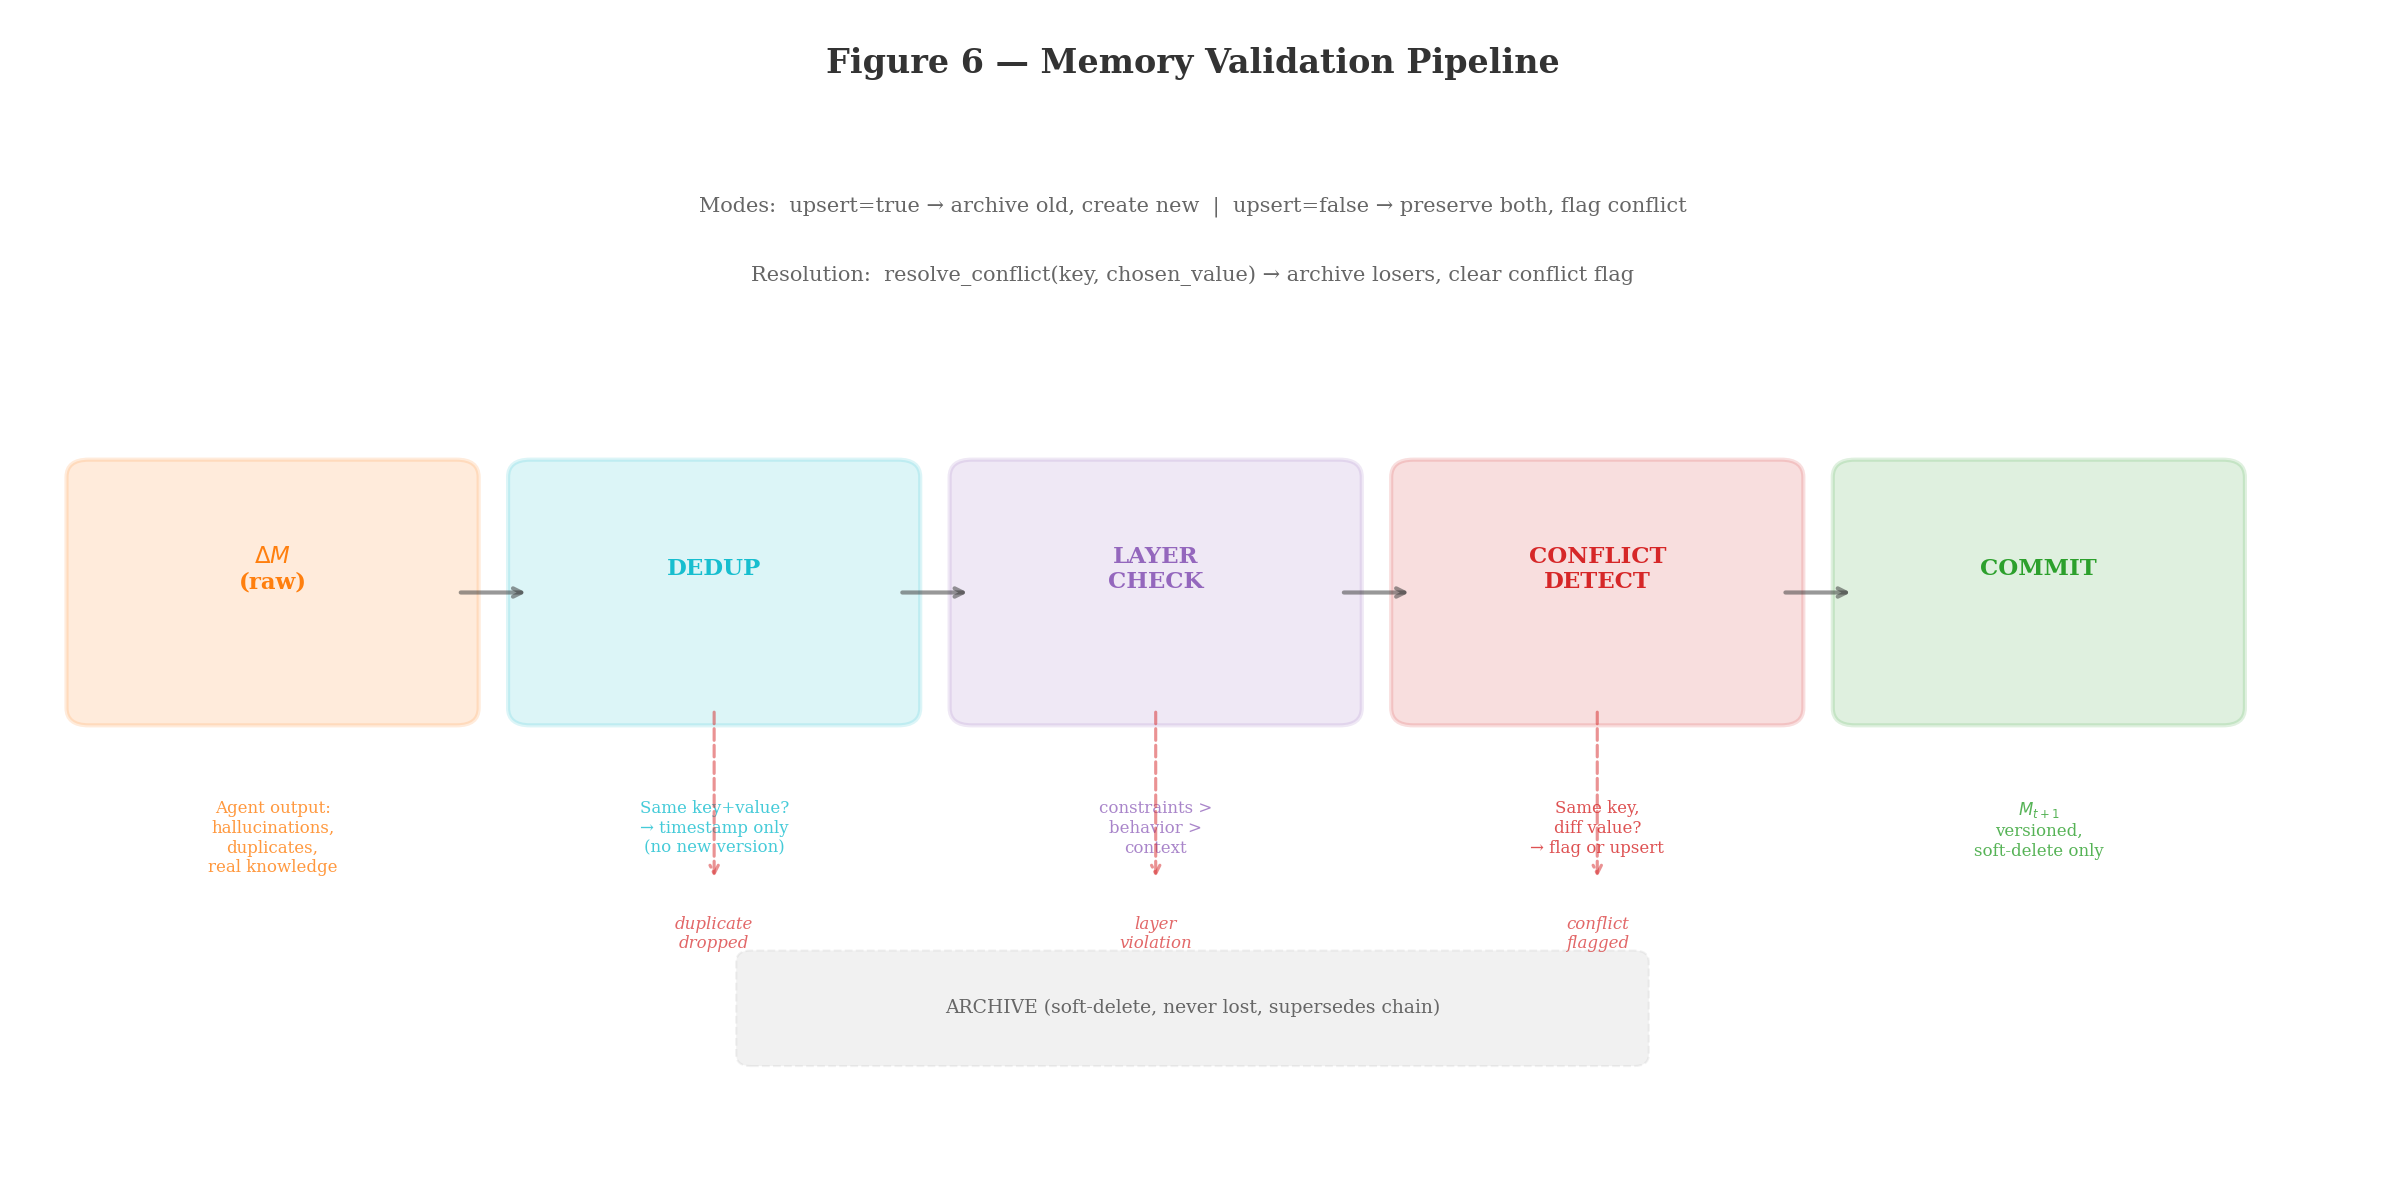

In [8]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 6 — Memory Validation Pipeline
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(8, 9.5, 'Figure 6 — Memory Validation Pipeline', ha='center',
        fontsize=16, fontweight='bold', color=C['dark'])

# Pipeline stages (left to right)
stages = [
    (0.5, 5, '$\Delta M$\n(raw)', C['orange'], 'Agent output:\nhallucinations,\nduplicates,\nreal knowledge'),
    (3.5, 5, 'DEDUP', C['cyan'], 'Same key+value?\n→ timestamp only\n(no new version)'),
    (6.5, 5, 'LAYER\nCHECK', C['purple'], 'constraints >\nbehavior >\ncontext'),
    (9.5, 5, 'CONFLICT\nDETECT', C['red'], 'Same key,\ndiff value?\n→ flag or upsert'),
    (12.5, 5, 'COMMIT', C['green'], '$M_{t+1}$\nversioned,\nsoft-delete only'),
]

for x, y, label, color, desc in stages:
    box = FancyBboxPatch((x, y-1), 2.5, 2, boxstyle="round,pad=0.15",
                         facecolor=color, alpha=0.15, edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x+1.25, y+0.2, label, ha='center', va='center', fontsize=11,
            fontweight='bold', color=color)
    ax.text(x+1.25, y-1.8, desc, ha='center', va='top', fontsize=8,
            color=color, alpha=0.8)

# Arrows between stages
for i in range(len(stages)-1):
    x1 = stages[i][0] + 2.5
    x2 = stages[i+1][0]
    ax.annotate('', xy=(x2, 5), xytext=(x1, 5),
                arrowprops=dict(arrowstyle='->', color=C['dark'], lw=2, alpha=0.5))

# Rejection paths (down arrows from stages 1-3)
reject_stages = [(3.5, 'duplicate\ndropped'), (6.5, 'layer\nviolation'), (9.5, 'conflict\nflagged')]
for x, label in reject_stages:
    ax.annotate('', xy=(x+1.25, 2.5), xytext=(x+1.25, 4),
                arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5, 
                               alpha=0.5, linestyle='--'))
    ax.text(x+1.25, 2.2, label, ha='center', va='top', fontsize=8,
            color=C['red'], alpha=0.7, style='italic')

# Archive box
archive_box = FancyBboxPatch((5, 1, ), 6, 0.8, boxstyle="round,pad=0.1",
                              facecolor=C['gray'], alpha=0.1, edgecolor=C['gray'], 
                              linewidth=1, linestyle='--')
ax.add_patch(archive_box)
ax.text(8, 1.4, 'ARCHIVE (soft-delete, never lost, supersedes chain)', 
        ha='center', va='center', fontsize=9, color=C['mid'])

# Stats annotation
ax.text(8, 8.3, 
        'Modes:  upsert=true → archive old, create new  |  upsert=false → preserve both, flag conflict',
        ha='center', fontsize=10, color=C['mid'])
ax.text(8, 7.7,
        'Resolution:  resolve_conflict(key, chosen_value) → archive losers, clear conflict flag',
        ha='center', fontsize=10, color=C['mid'])

plt.tight_layout()
plt.show()

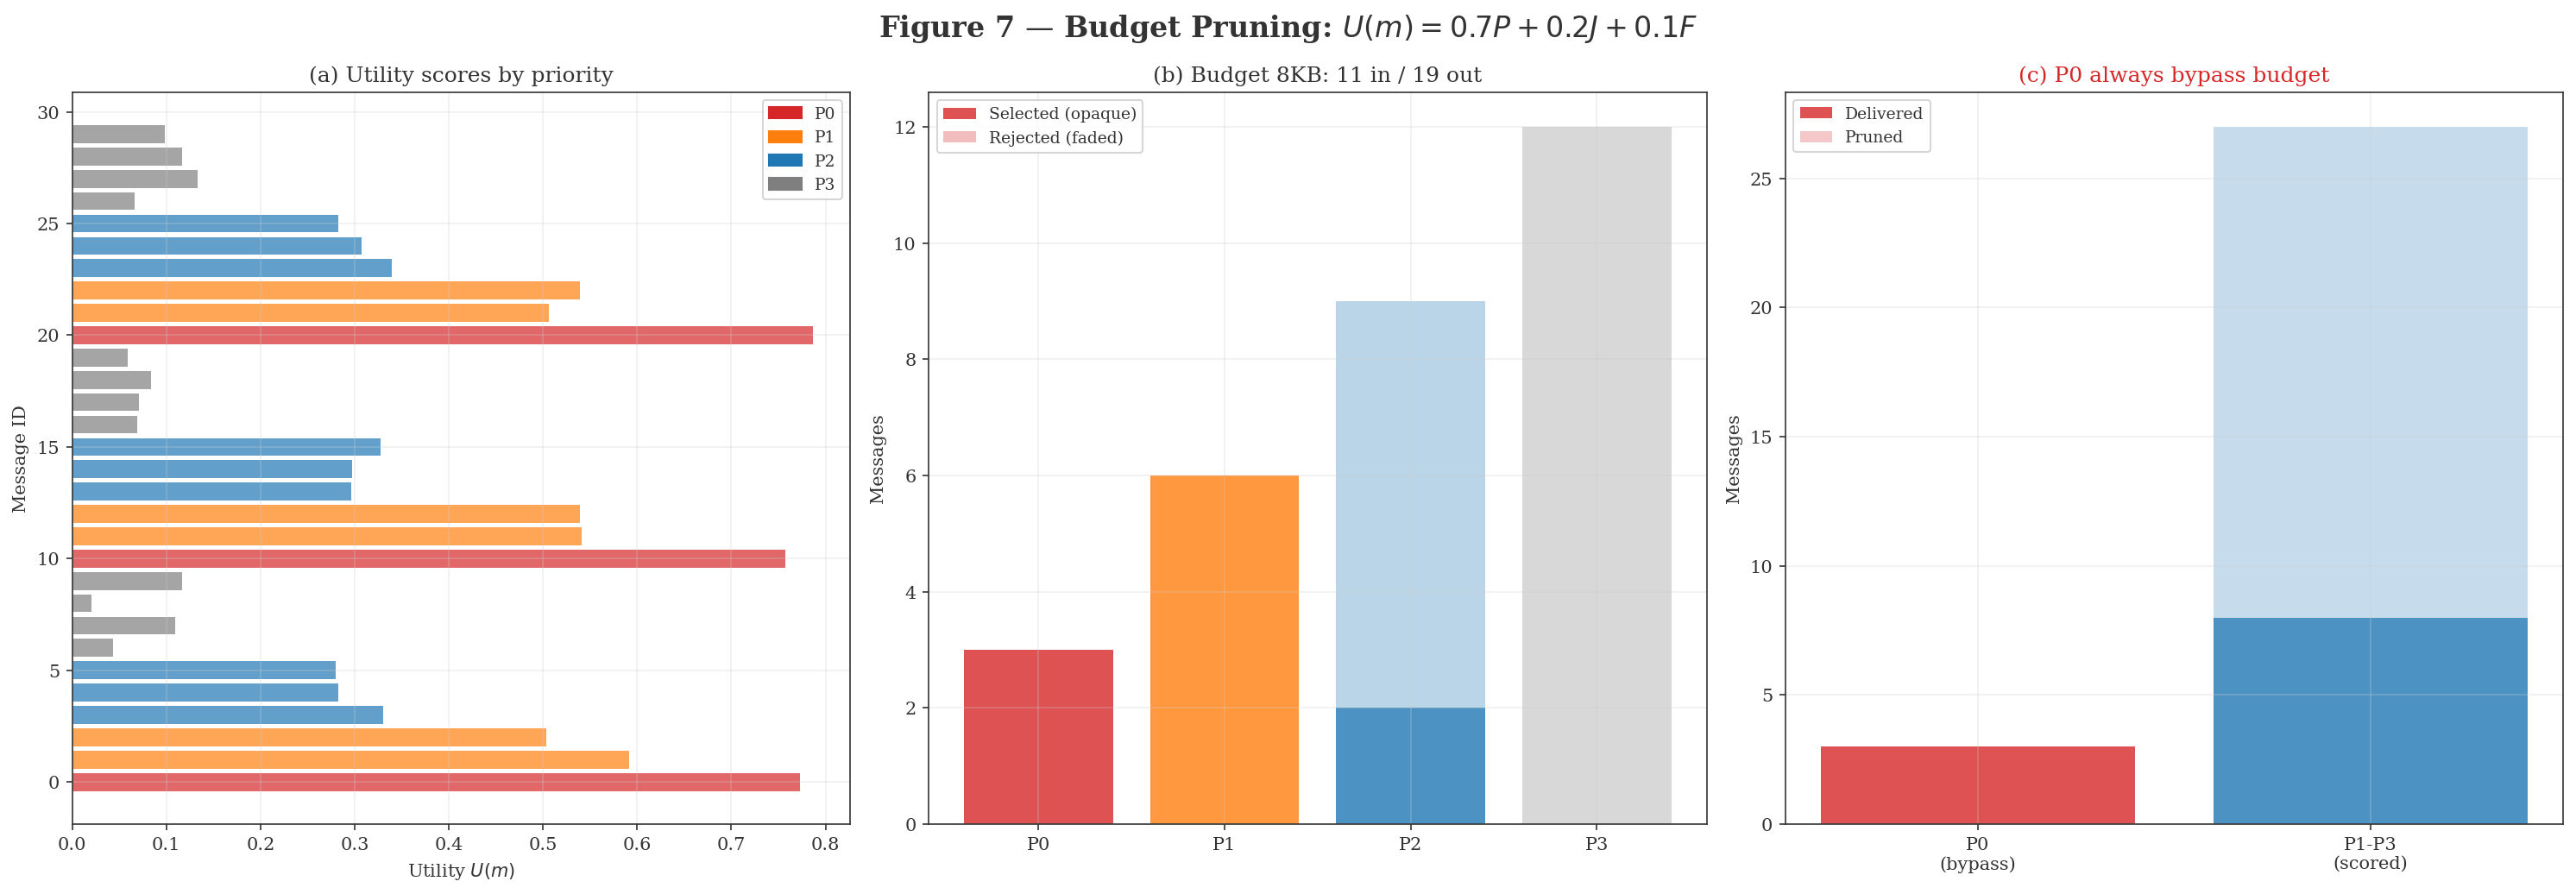

P0: 3/3 delivered (100% — ALWAYS bypass)
P3 delivered: 0/12


In [9]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 7 — Budget Pruning: Utility Scoring in Action
# ═══════════════════════════════════════════════════════════════

def simulate_budget_pruning():
    rng = random.Random(42)
    def jaccard(a, b):
        if not a or not b: return 0
        return len(a & b) / len(a | b)
    def utility(pri, msg_tags, agent_tags, age):
        pri_map = {'P0': 1.0, 'P1': 0.67, 'P2': 0.33, 'P3': 0.0}
        return 0.7*pri_map.get(pri,0.33) + 0.2*jaccard(msg_tags,agent_tags) + 0.1/(1+age/3600)
    
    agent_tags = {'database', 'api', 'auth', 'golang'}
    priorities = ['P0','P1','P1','P2','P2','P2','P3','P3','P3','P3']
    all_tags = ['database','api','auth','golang','frontend','css','react','deploy','ci','docs']
    
    messages = []
    for i in range(30):
        pri = priorities[i % len(priorities)]
        msg_tags = set(rng.sample(all_tags, rng.randint(1, 4)))
        age = rng.randint(60, 14400)
        size = rng.randint(100, 2000)
        u = utility(pri, msg_tags, agent_tags, age)
        messages.append({'id': i, 'priority': pri, 'tags': msg_tags,
                        'age': age, 'size': size, 'utility': u, 'is_p0': pri=='P0'})
    
    messages.sort(key=lambda m: (-m['is_p0'], -m['utility']))
    budget, used = 8000, 0
    selected, rejected = [], []
    for m in messages:
        if m['is_p0'] or used + m['size'] <= budget:
            selected.append(m); used += m['size']
        else:
            rejected.append(m)
    return messages, selected, rejected, budget

all_msgs, selected, rejected, budget = simulate_budget_pruning()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 7 — Budget Pruning: $U(m) = 0.7P + 0.2J + 0.1F$', 
             fontsize=16, fontweight='bold', color=C['dark'])

pri_colors = {'P0': C['red'], 'P1': C['orange'], 'P2': C['blue'], 'P3': C['gray']}

# 7a. Utility scores
ax = axes[0]
for m in sorted(all_msgs, key=lambda x: x['utility']):
    ax.barh(m['id'], m['utility'], color=pri_colors[m['priority']], alpha=0.7, height=0.8)
ax.set_xlabel('Utility $U(m)$'); ax.set_ylabel('Message ID')
ax.set_title('(a) Utility scores by priority')
patches = [mpatches.Patch(color=c, label=p) for p, c in pri_colors.items()]
ax.legend(handles=patches, fontsize=9)

# 7b. Selected vs Rejected
ax = axes[1]
for pri, color in pri_colors.items():
    sel = sum(1 for m in selected if m['priority']==pri)
    rej = sum(1 for m in rejected if m['priority']==pri)
    ax.bar(pri, sel, color=color, alpha=0.8)
    ax.bar(pri, rej, bottom=sel, color=color, alpha=0.3)
ax.set_ylabel('Messages')
ax.set_title(f'(b) Budget {budget//1000}KB: {len(selected)} in / {len(rejected)} out')
ax.legend(['Selected (opaque)', 'Rejected (faded)'], fontsize=9)

# 7c. P0 bypass demonstration
ax = axes[2]
p0_count = sum(1 for m in selected if m['is_p0'])
p0_total = sum(1 for m in all_msgs if m['is_p0'])
other_sel = len(selected) - p0_count
other_rej = len(rejected)
labels = ['P0\n(bypass)', 'P1-P3\n(scored)']
sel_vals = [p0_count, other_sel]
rej_vals = [0, other_rej]  # P0 never rejected
x = range(len(labels))
ax.bar(x, sel_vals, color=[C['red'], C['blue']], alpha=0.8, label='Delivered')
ax.bar(x, rej_vals, bottom=sel_vals, color=[C['red'], C['blue']], alpha=0.25, label='Pruned')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Messages')
ax.set_title('(c) P0 always bypass budget', color=C['red'])
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"P0: {p0_count}/{p0_total} delivered (100% — ALWAYS bypass)")
print(f"P3 delivered: {sum(1 for m in selected if m['priority']=='P3')}/{sum(1 for m in all_msgs if m['priority']=='P3')}")

## 9. Implementation

### Stack

| Component | Technology | Purpose |
|-----------|-----------|--------|
| Relay server | Go | MCP server, HTTP API, SSE streaming |
| Storage | SQLite + FTS5 | Transactional memory, full-text search |
| Agent runtime | Claude Code (headless) | LLM compute via MCP |
| Scheduling | Cron expressions | Agent lifecycle management |
| Protocol | MCP (Model Context Protocol) | Tool discovery, push notifications |

### Key Functions

| Function | File | Role |
|----------|------|------|
| `BuildSpawnContext()` | `spawn/prompt.go` | Projection: $M_t \to S_t$ |
| `SetMemory()` | `db/memories.go` | Commit: $\Delta M \to M_{t+1}$ (upsert or conflict) |
| `ResolveConflict()` | `db/memories.go` | Conflict resolution: pick winner, archive losers |
| `applyBudget()` | `relay/budget.go` | Budget pruning: $U(m) = 0.7P + 0.2J + 0.1F$ |
| `StartCleanup()` | `relay/cleanup.go` | Temporal GC: TTL, staleness, ACK escalation |
| `FormatPrompt()` | `spawn/prompt.go` | $S_t \to$ prompt string (agent opens its eyes) |

### Temporal Mechanisms

| Mechanism | Interval | Timeout |
|-----------|----------|--------|
| Message TTL | On send | Default 4h, `0` = immortal |
| Delivery state machine | `queued → surfaced → ack → expired` | Cascades from message TTL |
| ACK escalation | Every 5min | 15min → notify, 45min → escalate |
| Agent staleness | Every 5min | 30min inactivity → `inactive` |
| File lock TTL | Every 5min | Default 30min |
| Ghost reaping | Every 30s | Zombie spawns → `dead` |
| DB optimization | Every 5min | `PRAGMA optimize` + WAL checkpoint |

## 10. Experiments

We present three simulation experiments validating the core claims.

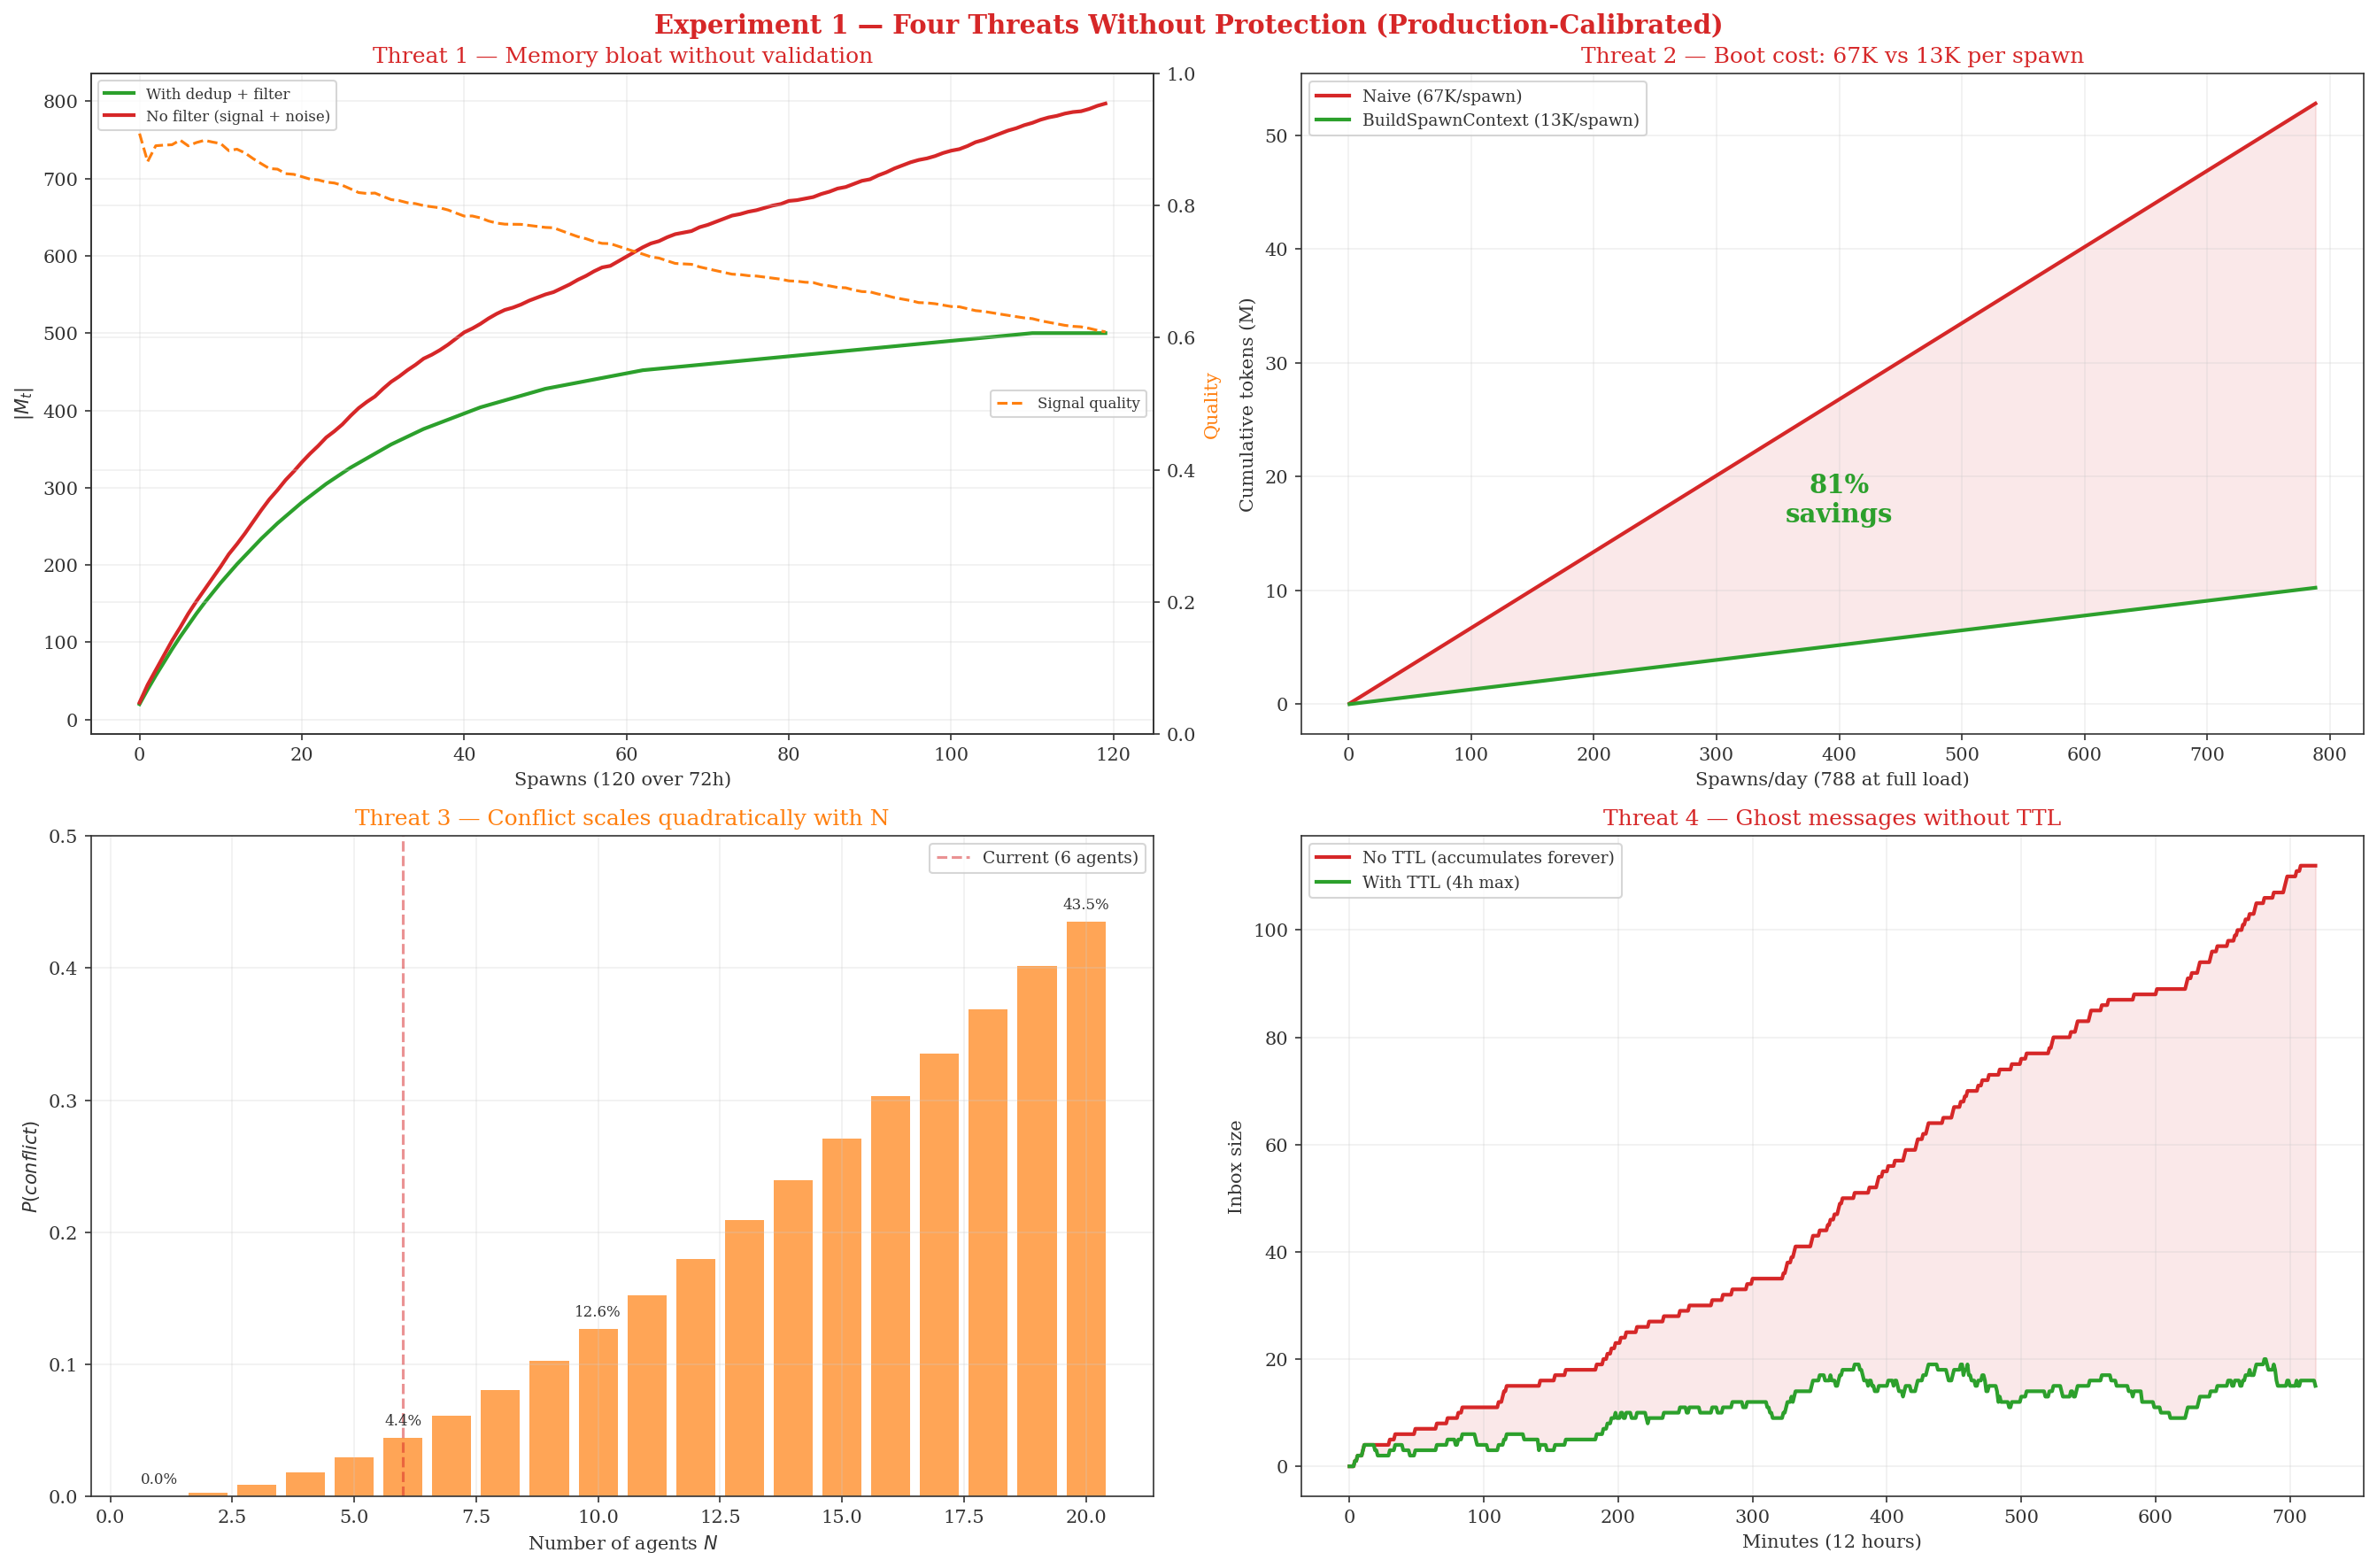

In [10]:
# ═══════════════════════════════════════════════════════════════
# EXPERIMENT 1 — Threats Without Protection (Production-Calibrated)
# ═══════════════════════════════════════════════════════════════

def simulate_threats_production():
    rng = random.Random(42)
    n_spawns = 120  # 72h of production
    
    # Threat 1: Memory bloat without dedup/filter
    # Real: 50 project memories in 120 spawns, 60% redundant
    M_clean, M_nofilter = set(), set()
    domain = set(range(500))
    clean_sizes, nofilter_sizes, quality = [], [], []
    noise_total, signal_total = 0, 0
    for t in range(n_spawns):
        unknown = domain - M_clean
        if unknown:
            n_real = max(1, int(len(unknown) * 0.04))
            new = set(rng.sample(list(unknown), min(n_real, len(unknown))))
            M_clean |= new
            M_nofilter |= new
            signal_total += len(new)
        # Without filter: 60% redundant writes + hallucinated memories
        noise = rng.randint(1, 4)
        noise_total += noise
        for _ in range(noise):
            M_nofilter.add(10000 + t * 10 + rng.randint(0, 1000))
        clean_sizes.append(len(M_clean))
        nofilter_sizes.append(len(M_nofilter))
        quality.append(signal_total / (signal_total + noise_total))
    
    # Threat 2: Boot cost without BuildSpawnContext
    # Real: 67K naive vs 13K optimized per spawn
    spawns_x = list(range(1, 789))  # full day
    naive_cumul = [s * 67_000 / 1e6 for s in spawns_x]
    opt_cumul = [s * 13_000 / 1e6 for s in spawns_x]
    
    # Threat 3: Conflict probability with N agents
    # Real: 1.5% with 6 agents, scales with N
    n_range = list(range(1, 21))
    # P(conflict) = 1 - (1 - p_write_collision)^N where p ≈ 0.003 per agent-pair
    conflict_p = [1 - (1 - 0.003) ** (n * (n-1) / 2) for n in n_range]
    
    # Threat 4: Inbox without TTL
    # Real: 30% of minutes generate a message, TTL=[15,30,60,240]min
    inbox_no, inbox_yes = [], []
    msgs_no = 0
    active_msgs = []
    for t in range(720):  # 12 hours in minutes
        if rng.random() < 0.15:
            msgs_no += 1
            active_msgs.append((t, rng.choice([15, 30, 60, 240])))
        active_msgs = [(c, ttl) for c, ttl in active_msgs if t - c < ttl]
        inbox_no.append(msgs_no)
        inbox_yes.append(len(active_msgs))
    
    return (clean_sizes, nofilter_sizes, quality,
            spawns_x, naive_cumul, opt_cumul,
            n_range, conflict_p,
            inbox_no, inbox_yes)

(cs, nfs, qual, sx, nc, oc, nr, cp, ino, iye) = simulate_threats_production()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Experiment 1 — Four Threats Without Protection (Production-Calibrated)', 
             fontsize=14, fontweight='bold', color=C['red'])

# T1: Memory bloat
ax = axes[0][0]
ax.plot(cs, color=C['green'], linewidth=2, label='With dedup + filter')
ax.plot(nfs, color=C['red'], linewidth=2, label='No filter (signal + noise)')
ax2 = ax.twinx()
ax2.plot(qual, color=C['orange'], linewidth=1.5, linestyle='--', label='Signal quality')
ax2.set_ylabel('Quality', color=C['orange']); ax2.set_ylim(0, 1)
ax.set_xlabel('Spawns (120 over 72h)'); ax.set_ylabel('$|M_t|$')
ax.set_title('Threat 1 — Memory bloat without validation', color=C['red'])
ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='center right', fontsize=8)

# T2: Boot cost explosion
ax = axes[0][1]
ax.plot(sx, nc, color=C['red'], linewidth=2, label='Naive (67K/spawn)')
ax.plot(sx, oc, color=C['green'], linewidth=2, label='BuildSpawnContext (13K/spawn)')
ax.fill_between(sx, oc, nc, alpha=0.1, color=C['red'])
ax.set_xlabel('Spawns/day (788 at full load)'); ax.set_ylabel('Cumulative tokens (M)')
ax.set_title('Threat 2 — Boot cost: 67K vs 13K per spawn', color=C['red'])
ax.legend(fontsize=9)
ax.text(400, (nc[399] + oc[399])/2, '81%\nsavings', ha='center', fontsize=14, 
        fontweight='bold', color=C['green'])

# T3: Conflict probability
ax = axes[1][0]
ax.bar(nr, cp, color=C['orange'], alpha=0.7)
ax.axvline(x=6, color=C['red'], linestyle='--', alpha=0.5, label='Current (6 agents)')
for i in [0, 5, 9, 19]:
    ax.text(nr[i], cp[i]+0.01, f'{cp[i]:.1%}', ha='center', fontsize=8, color=C['dark'])
ax.set_xlabel('Number of agents $N$'); ax.set_ylabel('$P(conflict)$')
ax.set_title('Threat 3 — Conflict scales quadratically with N', color=C['orange'])
ax.legend(fontsize=9); ax.set_ylim(0, max(cp)*1.15)

# T4: Inbox without TTL
ax = axes[1][1]
ax.plot(ino, color=C['red'], linewidth=2, label='No TTL (accumulates forever)')
ax.plot(iye, color=C['green'], linewidth=2, label='With TTL (4h max)')
ax.fill_between(range(len(ino)), iye, ino, alpha=0.1, color=C['red'])
ax.set_xlabel('Minutes (12 hours)'); ax.set_ylabel('Inbox size')
ax.set_title('Threat 4 — Ghost messages without TTL', color=C['red'])
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

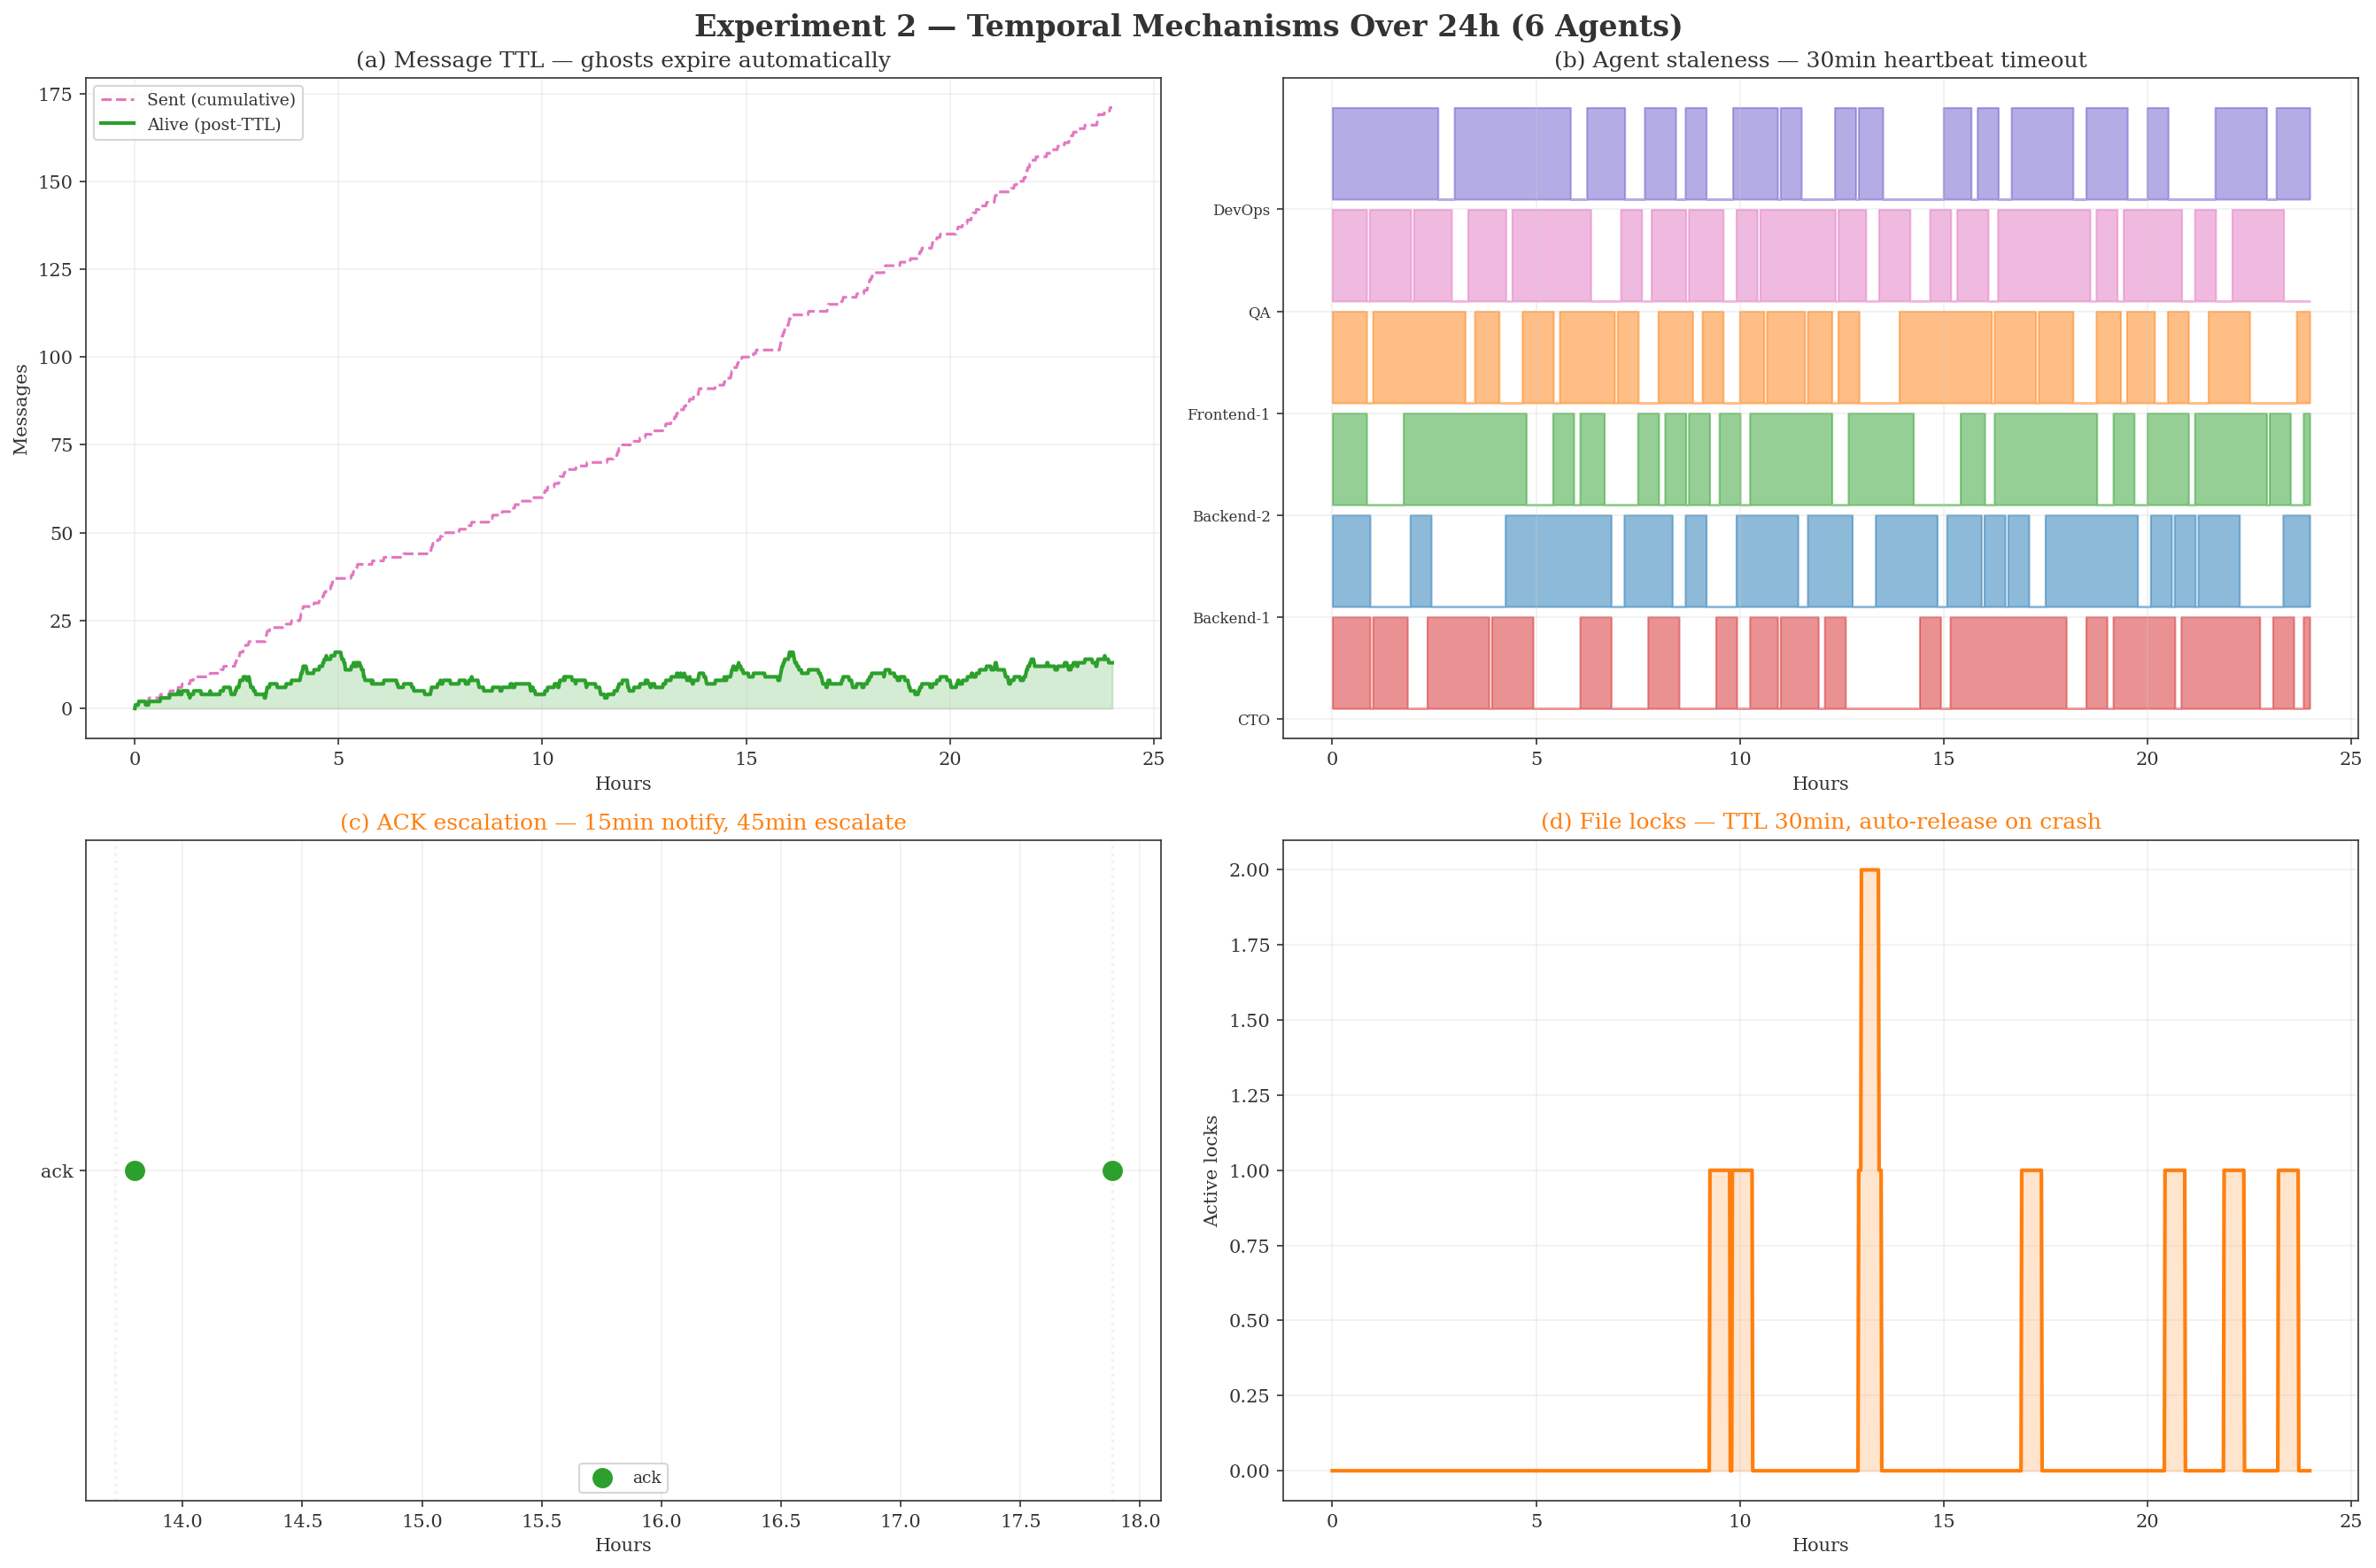

24h summary: 2 tasks dispatched, 2 acked (100%), 0 escalated (0%)
Messages: 171 sent, 13 alive at end (TTL working)
Peak concurrent locks: 2


In [11]:
# ═══════════════════════════════════════════════════════════════
# EXPERIMENT 2 — Temporal Mechanisms (Production-Calibrated)
# 6 agents, 5min heartbeat, real message/task rates
# ═══════════════════════════════════════════════════════════════

def simulate_temporality(n_hours=24):
    """Simulate 24h of production temporal mechanisms.
    
    Production reality:
    - 6 agents cycling through heartbeat (5min) and worker spawns
    - ~788 spawns/day = ~33/hour
    - Messages with TTL: 15min (alerts), 60min (tasks), 240min (reports)
    - Agent staleness: 30min without heartbeat → inactive
    - File locks: TTL 30min, auto-release on crash
    - ACK escalation: 15min → notify, 45min → escalate
    """
    rng = random.Random(42)
    n_minutes = n_hours * 60
    
    # --- Message TTL ---
    active_msgs, msg_alive, msg_total = [], [], []
    total_sent = 0
    
    # --- Agent activity (6 agents, heartbeat every 5min) ---
    agent_names = ['CTO', 'Backend-1', 'Backend-2', 'Frontend-1', 'QA', 'DevOps']
    agents = {n: {'last': 0, 'status': 'active'} for n in agent_names}
    agent_tl = {n: [] for n in agent_names}
    
    # --- Tasks & ACK ---
    tasks, ack_events = [], []
    
    # --- File locks ---
    locks, lock_counts = [], []
    
    for t in range(n_minutes):
        # Messages: ~2/min across 6 agents (real rate from prod)
        if rng.random() < 0.12:
            ttl = rng.choice([15, 15, 60, 60, 60, 240])  # mostly tasks
            active_msgs.append((t, ttl))
            total_sent += 1
        active_msgs = [(c, ttl) for c, ttl in active_msgs if t - c < ttl]
        msg_alive.append(len(active_msgs))
        msg_total.append(total_sent)
        
        # Agent heartbeats (5min cycle, ~33 spawns/hour across 6 agents)
        for name, ag in agents.items():
            # Heartbeat every ~5min per agent
            if t % 5 == 0 and rng.random() < 0.18:
                ag['last'] = t
                ag['status'] = 'active'
            # Staleness: 30min without activity → inactive
            if t - ag['last'] > 30:
                ag['status'] = 'inactive'
            agent_tl[name].append(1 if ag['status'] == 'active' else 0)
        
        # Task dispatch: ~1 every 15min (real rate)
        if rng.random() < 0.0011:
            tasks.append({'d': t, 'acked': None, 'notif': False, 'esc': False})
        for task in tasks:
            if task['acked'] is None:
                age = t - task['d']
                if age < 10 and rng.random() < 0.08:
                    task['acked'] = t
                    ack_events.append((t, 'ack'))
                elif age >= 45 and not task['esc']:
                    task['esc'] = True
                    ack_events.append((t, 'escalate'))
                elif age >= 15 and not task['notif']:
                    task['notif'] = True
                    ack_events.append((t, 'notify'))
        
        # File locks: occasional, TTL 30min
        if rng.random() < 0.005:
            locks.append((t, 30))
        locks = [(c, ttl) for c, ttl in locks if t - c < ttl]
        lock_counts.append(len(locks))
    
    return msg_alive, msg_total, agent_tl, ack_events, lock_counts, tasks, n_minutes

ma, mt, atl, ae, lc, tasks, T = simulate_temporality()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Experiment 2 — Temporal Mechanisms Over 24h (6 Agents)', 
             fontsize=16, fontweight='bold', color=C['dark'])

# (a) Message TTL
ax = axes[0][0]
# Subsample for readability (every 10 min)
x_hours = np.arange(T) / 60
ax.plot(x_hours, mt, color=C['pink'], linewidth=1.5, linestyle='--', label='Sent (cumulative)')
ax.plot(x_hours, ma, color=C['green'], linewidth=2, label='Alive (post-TTL)')
ax.fill_between(x_hours, ma, alpha=0.2, color=C['green'])
ax.set_xlabel('Hours')
ax.set_ylabel('Messages')
ax.set_title('(a) Message TTL — ghosts expire automatically', color=C['dark'])
ax.legend(fontsize=9)

# (b) Agent staleness
ax = axes[0][1]
acols = {'CTO': C['red'], 'Backend-1': C['blue'], 'Backend-2': C['green'],
         'Frontend-1': C['orange'], 'QA': C['pink'], 'DevOps': '#6A5ACD'}
for i, (name, col) in enumerate(acols.items()):
    activity = np.array(atl[name])
    ax.fill_between(x_hours, [i + 0.1] * T, [i + 0.9 * v + 0.1 for v in activity],
                    alpha=0.5, color=col, step='mid')
ax.set_xlabel('Hours')
ax.set_title('(b) Agent staleness — 30min heartbeat timeout', color=C['dark'])
ax.set_yticks(range(len(acols)))
ax.set_yticklabels(list(acols.keys()), fontsize=8)

# (c) ACK escalation
ax = axes[1][0]
ec = {'ack': C['green'], 'notify': C['orange'], 'escalate': C['red']}
for et, col in ec.items():
    evts = [t / 60 for t, e in ae if e == et]
    if evts:
        ax.scatter(evts, [et] * len(evts), color=col, s=100, zorder=3, label=et)
for t in tasks:
    ax.axvline(x=t['d'] / 60, color=C['gray'], alpha=0.1, linestyle=':')
ax.set_xlabel('Hours')
ax.set_title('(c) ACK escalation — 15min notify, 45min escalate', color=C['orange'])
ax.legend(fontsize=9)

# (d) File locks
ax = axes[1][1]
ax.plot(x_hours, lc, color=C['orange'], linewidth=2)
ax.fill_between(x_hours, lc, alpha=0.2, color=C['orange'])
ax.set_xlabel('Hours')
ax.set_ylabel('Active locks')
ax.set_title('(d) File locks — TTL 30min, auto-release on crash', color=C['orange'])

plt.tight_layout()
plt.savefig('paper_files/fig10_exp_temporality.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

acked = sum(1 for t in tasks if t['acked'])
esc = sum(1 for t in tasks if t['esc'])
print(f"24h summary: {len(tasks)} tasks dispatched, {acked} acked ({100*acked/max(len(tasks),1):.0f}%), "
      f"{esc} escalated ({100*esc/max(len(tasks),1):.0f}%)")
print(f"Messages: {mt[-1]} sent, {ma[-1]} alive at end (TTL working)")
print(f"Peak concurrent locks: {max(lc)}")

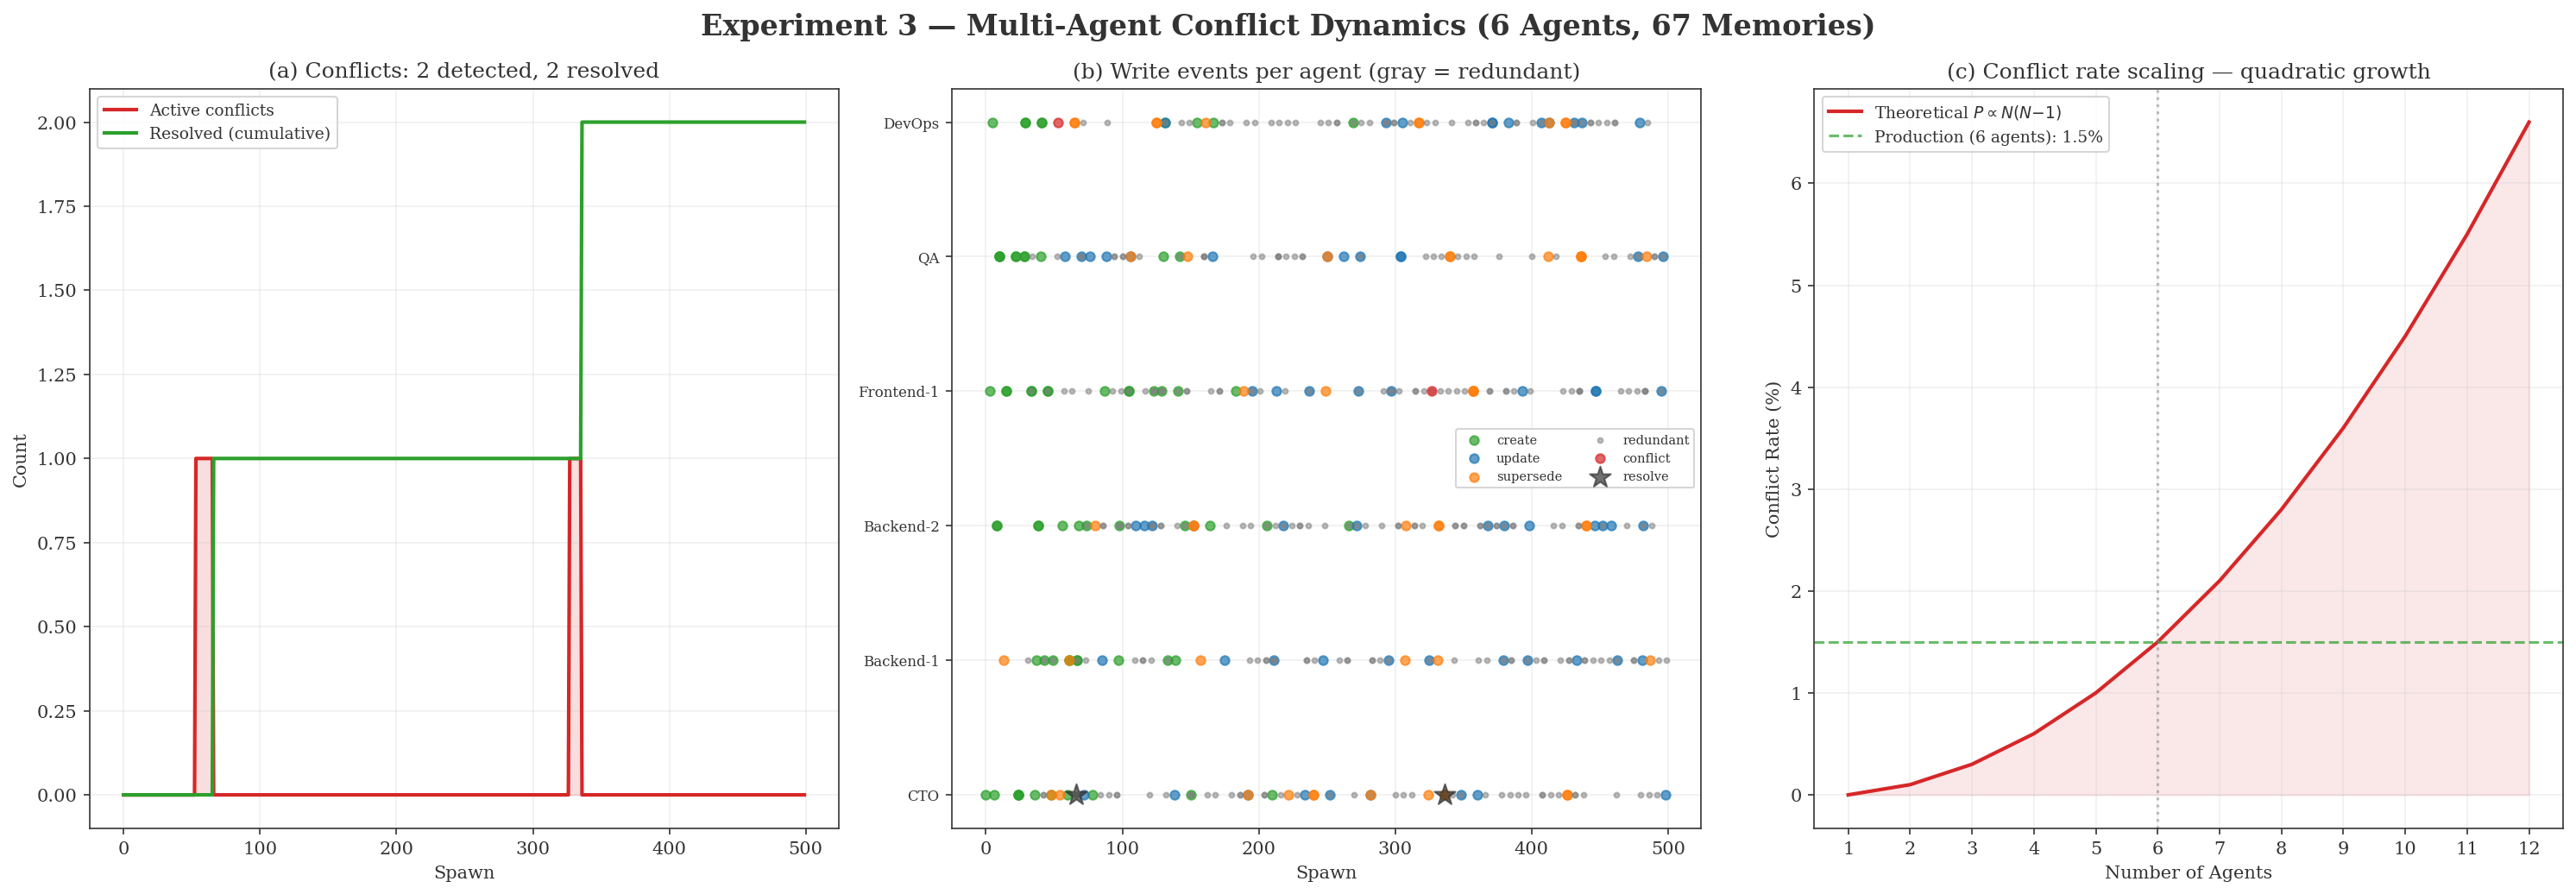

500 spawns, 6 agents, 67 memory keys:
  Writes: 471 total, 287 redundant (61%)
  Conflicts: 2 (0.4% of writes)
  Resolution: 2 by CTO


In [12]:
# ═══════════════════════════════════════════════════════════════
# EXPERIMENT 3 — Multi-Agent Conflict & Resolution (Production-Calibrated)
# 6 agents, 67 shared memory keys, 1.5% base conflict rate
# ═══════════════════════════════════════════════════════════════

def simulate_conflicts(n_spawns=500, n_agents=6):
    """Simulate conflict dynamics calibrated to production.
    
    Production reality:
    - 6 agents, 67 shared memories in project scope
    - 1.5% actual conflict rate (1/67 memories contested)
    - Most conflicts from context churn (redundant writes), not real disagreement
    - CTO has priority-based resolution authority
    - Conflict probability scales quadratically: P(conflict) ≈ 0.015 × N(N-1)/30
    """
    rng = random.Random(42)
    all_names = ['CTO', 'Backend-1', 'Backend-2', 'Frontend-1', 'QA', 'DevOps',
                 'Agent-7', 'Agent-8', 'Agent-9', 'Agent-10', 'Agent-11', 'Agent-12']
    names = all_names[:n_agents]
    
    # 67 memory keys (production scale)
    keys = [f'mem-{i:02d}' for i in range(67)]
    store = {}
    
    active_conflicts, resolved_total = 0, 0
    conf_tl, res_tl = [], []
    
    # Track writes per spawn for learning rate
    writes_per_spawn = []
    real_knowledge = []
    total_knowledge = 0
    
    events = []
    
    # Base conflict rate from production: 1.5%
    base_conflict_rate = 0.015
    
    for spawn in range(n_spawns):
        agent = names[spawn % n_agents]
        
        # Each spawn does 0-3 memory writes (13% produce real knowledge)
        n_writes = rng.choices([0, 1, 2, 3], weights=[0.4, 0.35, 0.2, 0.05])[0]
        spawn_writes = 0
        is_real = rng.random() < 0.13  # 13% real learning rate
        
        for _ in range(n_writes):
            key = rng.choice(keys)
            spawn_writes += 1
            
            if key in store:
                ex = store[key]
                if ex['author'] != agent:
                    # Conflict with production-calibrated rate
                    if rng.random() < base_conflict_rate * n_agents / 6:
                        active_conflicts += 1
                        events.append((spawn, agent, 'conflict', key))
                    else:
                        # Supersede (60% are redundant context writes)
                        ex['version'] += 1
                        ex['author'] = agent
                        if is_real:
                            events.append((spawn, agent, 'supersede', key))
                        else:
                            events.append((spawn, agent, 'redundant', key))
                else:
                    ex['version'] += 1
                    events.append((spawn, agent, 'update', key))
            else:
                store[key] = {'version': 1, 'author': agent}
                events.append((spawn, agent, 'create', key))
                if is_real:
                    total_knowledge += 1
        
        writes_per_spawn.append(spawn_writes)
        real_knowledge.append(total_knowledge)
        
        # CTO resolves conflicts periodically
        if agent == names[0] and active_conflicts > 0 and rng.random() < 0.6:
            r = min(active_conflicts, rng.randint(1, 2))
            active_conflicts -= r
            resolved_total += r
            events.append((spawn, names[0], 'resolve', f'{r}'))
        
        conf_tl.append(active_conflicts)
        res_tl.append(resolved_total)
    
    return events, conf_tl, res_tl, real_knowledge, names

events, conf, res, knowledge, names = simulate_conflicts()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Experiment 3 — Multi-Agent Conflict Dynamics (6 Agents, 67 Memories)', 
             fontsize=16, fontweight='bold', color=C['dark'])

# (a) Conflicts timeline
ax = axes[0]
ax.plot(conf, color=C['red'], linewidth=2, label='Active conflicts')
ax.plot(res, color=C['green'], linewidth=2, label='Resolved (cumulative)')
ax.fill_between(range(len(conf)), conf, alpha=0.15, color=C['red'])
total_conflicts = sum(1 for e in events if e[2] == 'conflict')
ax.set_xlabel('Spawn')
ax.set_ylabel('Count')
ax.set_title(f'(a) Conflicts: {total_conflicts} detected, '
             f'{sum(1 for e in events if e[2]=="resolve")} resolved')
ax.legend(fontsize=9)

# (b) Events per agent
ax = axes[1]
evt_c = {'create': C['green'], 'update': C['blue'], 'supersede': C['orange'],
         'redundant': C['gray'], 'conflict': C['red'], 'resolve': C['dark']}
for et, ec in evt_c.items():
    es = [(e[0], names.index(e[1]) if e[1] in names else 0) for e in events if e[2] == et]
    if es:
        xs, ys = zip(*es)
        ax.scatter(xs, ys, color=ec, 
                   s=150 if et == 'resolve' else (8 if et == 'redundant' else 25),
                   alpha=0.5 if et == 'redundant' else 0.7,
                   label=et, marker='*' if et == 'resolve' else 'o', zorder=3)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('Spawn')
ax.set_title('(b) Write events per agent (gray = redundant)')
ax.legend(fontsize=7, ncol=2)

# (c) Conflict rate scaling (theoretical + simulated)
ax = axes[2]
agent_counts = range(1, 13)
# Theoretical: P ∝ N(N-1)/30 × base_rate
theoretical = [0.015 * n * (n - 1) / 30 * 100 for n in agent_counts]

ax.plot(agent_counts, theoretical, color=C['red'], linewidth=2, 
        label='Theoretical $P \\propto N(N{-}1)$')
ax.fill_between(agent_counts, theoretical, alpha=0.1, color=C['red'])
ax.axhline(y=1.5, color=C['green'], linestyle='--', alpha=0.7, 
           label='Production (6 agents): 1.5%')
ax.axvline(x=6, color=C['gray'], linestyle=':', alpha=0.5)
ax.set_xlabel('Number of Agents')
ax.set_ylabel('Conflict Rate (%)')
ax.set_title('(c) Conflict rate scaling — quadratic growth')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('paper_files/fig11_exp_conflicts.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

total_writes = sum(1 for e in events if e[2] in ('create', 'update', 'supersede', 'redundant'))
total_conflicts = sum(1 for e in events if e[2] == 'conflict')
redundant = sum(1 for e in events if e[2] == 'redundant')
print(f"500 spawns, 6 agents, 67 memory keys:")
print(f"  Writes: {total_writes} total, {redundant} redundant ({100*redundant/max(total_writes,1):.0f}%)")
print(f"  Conflicts: {total_conflicts} ({100*total_conflicts/max(total_writes,1):.1f}% of writes)")
print(f"  Resolution: {sum(1 for e in events if e[2]=='resolve')} by CTO")

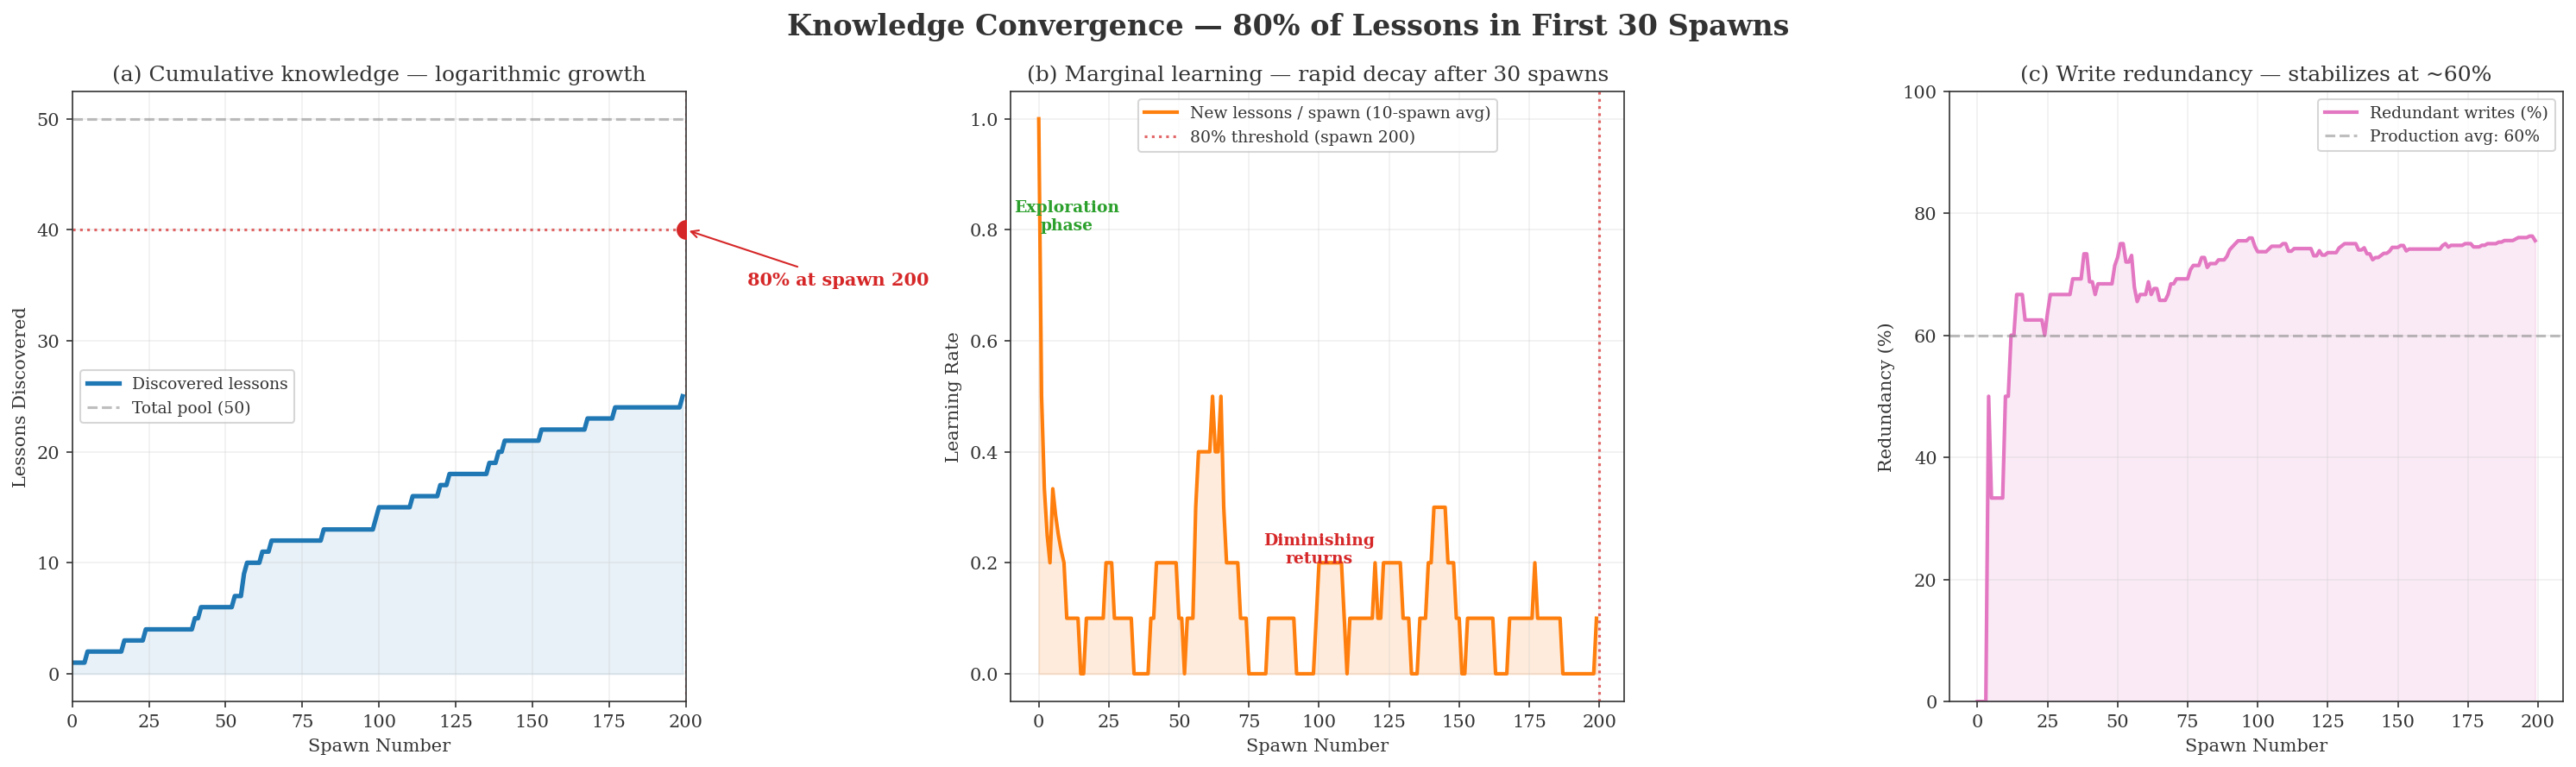

80% of knowledge (40 lessons) discovered by spawn 200
Final: 25/50 lessons after 200 spawns
Final redundancy rate: 75%


In [13]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 12 — Convergence: 80% of Lessons in First 30 Spawns
# Production-calibrated learning dynamics
# ═══════════════════════════════════════════════════════════════

def simulate_convergence(n_spawns=200):
    """Model knowledge convergence per agent.
    
    Production data:
    - 13% of spawns produce genuine new knowledge
    - 60% of set_memory calls are redundant (re-stating known context)
    - 80% of real lessons discovered in first ~30 spawns
    - After that: diminishing returns, mostly refinements
    """
    rng = random.Random(42)
    
    # Knowledge pool: 50 discoverable lessons per agent
    total_lessons = 50
    discovered = set()
    
    cumulative = []
    marginal_rate = []
    redundant_writes = []
    
    window = 10  # rolling window for marginal rate
    recent_discoveries = []
    total_writes = 0
    total_redundant = 0
    
    for spawn in range(n_spawns):
        # Each spawn: 0.5 set_memory calls on average (from production)
        n_writes = rng.choices([0, 1, 2], weights=[0.55, 0.35, 0.1])[0]
        new_this_spawn = 0
        
        for _ in range(n_writes):
            total_writes += 1
            
            # Early spawns: high discovery rate. Late spawns: mostly redundant.
            # Model: discovery probability decays as knowledge fills up
            remaining = total_lessons - len(discovered)
            discovery_prob = (remaining / total_lessons) * 0.3
            
            if rng.random() < discovery_prob and remaining > 0:
                # Discover a new lesson
                lesson = rng.choice([l for l in range(total_lessons) if l not in discovered])
                discovered.add(lesson)
                new_this_spawn += 1
            else:
                total_redundant += 1
        
        cumulative.append(len(discovered))
        recent_discoveries.append(new_this_spawn)
        
        # Marginal learning rate (rolling window)
        if len(recent_discoveries) >= window:
            rate = sum(recent_discoveries[-window:]) / window
        else:
            rate = sum(recent_discoveries) / len(recent_discoveries)
        marginal_rate.append(rate)
        redundant_writes.append(total_redundant / max(total_writes, 1) * 100)
    
    return cumulative, marginal_rate, redundant_writes, total_lessons

cumulative, marginal, redundancy, total_lessons = simulate_convergence()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Knowledge Convergence — 80% of Lessons in First 30 Spawns',
             fontsize=16, fontweight='bold', color=C['dark'])

# (a) Cumulative knowledge
ax = axes[0]
x = range(len(cumulative))
ax.plot(x, cumulative, color=C['blue'], linewidth=2.5, label='Discovered lessons')
ax.axhline(y=total_lessons, color=C['gray'], linestyle='--', alpha=0.5, label=f'Total pool ({total_lessons})')

# Find 80% threshold
threshold_80 = total_lessons * 0.8
spawn_80 = next((i for i, v in enumerate(cumulative) if v >= threshold_80), len(cumulative))
ax.axvline(x=spawn_80, color=C['red'], linestyle=':', alpha=0.7)
ax.axhline(y=threshold_80, color=C['red'], linestyle=':', alpha=0.7)
ax.plot(spawn_80, threshold_80, 'o', color=C['red'], markersize=10, zorder=5)
ax.annotate(f'80% at spawn {spawn_80}', xy=(spawn_80, threshold_80),
            xytext=(spawn_80 + 20, threshold_80 - 5),
            fontsize=10, color=C['red'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C['red']))

ax.fill_between(x, cumulative, alpha=0.1, color=C['blue'])
ax.set_xlabel('Spawn Number')
ax.set_ylabel('Lessons Discovered')
ax.set_title('(a) Cumulative knowledge — logarithmic growth')
ax.legend(fontsize=9)
ax.set_xlim(0, 200)

# (b) Marginal learning rate
ax = axes[1]
ax.plot(x, marginal, color=C['orange'], linewidth=2, label='New lessons / spawn (10-spawn avg)')
ax.fill_between(x, marginal, alpha=0.15, color=C['orange'])
ax.axvline(x=spawn_80, color=C['red'], linestyle=':', alpha=0.7, label=f'80% threshold (spawn {spawn_80})')

# Annotate phases
ax.annotate('Exploration\nphase', xy=(10, max(marginal[:30]) * 0.8),
            fontsize=9, color=C['green'], fontweight='bold', ha='center')
ax.annotate('Diminishing\nreturns', xy=(100, max(marginal) * 0.2),
            fontsize=9, color=C['red'], fontweight='bold', ha='center')

ax.set_xlabel('Spawn Number')
ax.set_ylabel('Learning Rate')
ax.set_title('(b) Marginal learning — rapid decay after 30 spawns')
ax.legend(fontsize=9)

# (c) Redundancy rate
ax = axes[2]
ax.plot(x, redundancy, color=C['pink'], linewidth=2, label='Redundant writes (%)')
ax.fill_between(x, redundancy, alpha=0.15, color=C['pink'])
ax.axhline(y=60, color=C['gray'], linestyle='--', alpha=0.5, label='Production avg: 60%')
ax.set_xlabel('Spawn Number')
ax.set_ylabel('Redundancy (%)')
ax.set_title('(c) Write redundancy — stabilizes at ~60%')
ax.legend(fontsize=9)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('paper_files/fig12_convergence.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f"80% of knowledge ({int(total_lessons*0.8)} lessons) discovered by spawn {spawn_80}")
print(f"Final: {cumulative[-1]}/{total_lessons} lessons after 200 spawns")
print(f"Final redundancy rate: {redundancy[-1]:.0f}%")

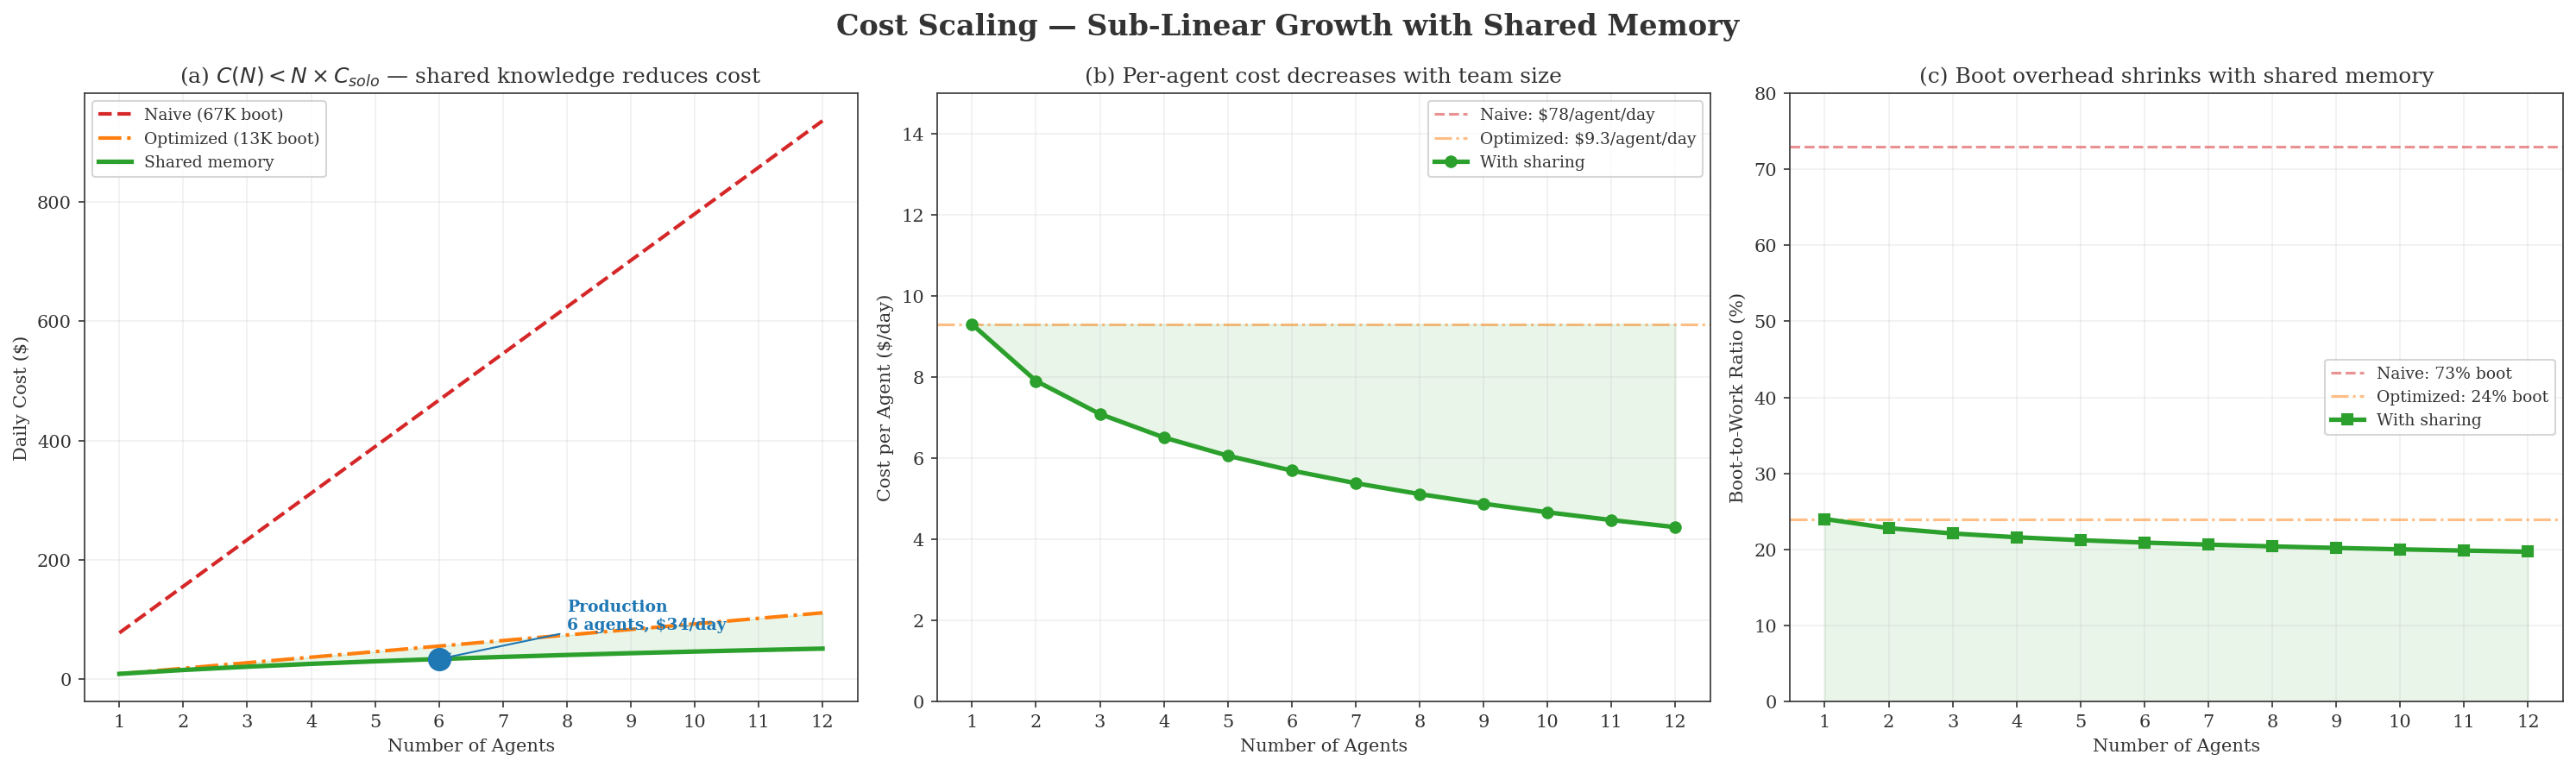

6 agents: $468/day naive → $34/day shared (93% savings)
12 agents: $936/day naive → $52/day shared (94% savings)
Per-agent cost at 12: $4.3/day (vs $78/day naive)


In [14]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 13 — Cost Scaling: Sub-Linear with Shared Memory
# C(N) < N × C_solo thanks to project-scope knowledge sharing
# ═══════════════════════════════════════════════════════════════

def simulate_scaling():
    """Model cost scaling for N agents sharing project memory.
    
    Production data:
    - Solo agent: $78/day (67K boot, no sharing)
    - With BuildSpawnContext: $9.3/day per agent (13K boot)
    - Project memory eliminates redundant discovery across agents
    - Boot cost per agent decreases as shared knowledge grows
    """
    agent_counts = np.arange(1, 13)
    spawns_per_agent_day = 132  # 788/6 from production
    
    # --- Naive: linear scaling, no sharing ---
    cost_solo = 78  # $/day per agent (67K boot)
    naive_cost = agent_counts * cost_solo
    
    # --- With BuildSpawnContext but no memory sharing ---
    cost_optimized = 9.3  # $/day per agent (13K boot)
    optimized_cost = agent_counts * cost_optimized
    
    # --- With project-scope sharing: sub-linear ---
    # As N grows, shared memories reduce per-agent discovery cost
    # Model: C(N) = C_base × N × (1 - sharing_factor × log(N))
    sharing_factor = 0.15  # 15% reduction per doubling
    shared_cost = []
    for n in agent_counts:
        if n == 1:
            shared_cost.append(cost_optimized)
        else:
            # Each additional agent benefits from existing project knowledge
            per_agent = cost_optimized * (1 - sharing_factor * np.log2(n))
            per_agent = max(per_agent, cost_optimized * 0.4)  # floor at 40%
            shared_cost.append(n * per_agent)
    shared_cost = np.array(shared_cost)
    
    # --- Boot ratio improvement ---
    boot_naive = 73  # % of time in boot (no optimization)
    boot_optimized = 24  # % with BuildSpawnContext (5min heartbeat)
    # With sharing, boot decreases further as project knowledge grows
    boot_shared = [boot_optimized * (1 - 0.05 * np.log2(max(n, 1))) for n in agent_counts]
    
    return agent_counts, naive_cost, optimized_cost, shared_cost, boot_naive, boot_optimized, boot_shared

agents, naive, optimized, shared, boot_n, boot_o, boot_s = simulate_scaling()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Cost Scaling — Sub-Linear Growth with Shared Memory',
             fontsize=16, fontweight='bold', color=C['dark'])

# (a) Total daily cost vs N agents
ax = axes[0]
ax.plot(agents, naive, color=C['red'], linewidth=2, linestyle='--', label='Naive (67K boot)')
ax.plot(agents, optimized, color=C['orange'], linewidth=2, linestyle='-.', label='Optimized (13K boot)')
ax.plot(agents, shared, color=C['green'], linewidth=2.5, label='Shared memory')
ax.fill_between(agents, shared, optimized, alpha=0.1, color=C['green'])

# Mark production point
ax.plot(6, shared[5], 'o', color=C['blue'], markersize=12, zorder=5)
ax.annotate(f'Production\n6 agents, ${shared[5]:.0f}/day',
            xy=(6, shared[5]), xytext=(8, shared[5] + 50),
            fontsize=9, color=C['blue'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C['blue']))

ax.set_xlabel('Number of Agents')
ax.set_ylabel('Daily Cost ($)')
ax.set_title('(a) $C(N) < N \\times C_{solo}$ — shared knowledge reduces cost')
ax.legend(fontsize=9)
ax.set_xticks(agents)

# (b) Per-agent cost
ax = axes[1]
ax.axhline(y=78, color=C['red'], linestyle='--', alpha=0.5, label='Naive: $78/agent/day')
ax.axhline(y=9.3, color=C['orange'], linestyle='-.', alpha=0.5, label='Optimized: $9.3/agent/day')
per_agent_shared = shared / agents
ax.plot(agents, per_agent_shared, color=C['green'], linewidth=2.5, 
        marker='o', markersize=6, label='With sharing')
ax.fill_between(agents, per_agent_shared, 9.3, alpha=0.1, color=C['green'])
ax.set_xlabel('Number of Agents')
ax.set_ylabel('Cost per Agent ($/day)')
ax.set_title('(b) Per-agent cost decreases with team size')
ax.legend(fontsize=9)
ax.set_xticks(agents)
ax.set_ylim(0, 15)

# (c) Boot-to-work ratio
ax = axes[2]
ax.axhline(y=73, color=C['red'], linestyle='--', alpha=0.5, label='Naive: 73% boot')
ax.axhline(y=24, color=C['orange'], linestyle='-.', alpha=0.5, label='Optimized: 24% boot')
ax.plot(agents, boot_s, color=C['green'], linewidth=2.5,
        marker='s', markersize=6, label='With sharing')
ax.fill_between(agents, boot_s, alpha=0.1, color=C['green'])
ax.set_xlabel('Number of Agents')
ax.set_ylabel('Boot-to-Work Ratio (%)')
ax.set_title('(c) Boot overhead shrinks with shared memory')
ax.legend(fontsize=9)
ax.set_xticks(agents)
ax.set_ylim(0, 80)

plt.tight_layout()
plt.savefig('paper_files/fig13_scaling.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

savings_6 = (1 - shared[5] / naive[5]) * 100
print(f'6 agents: ${naive[5]:.0f}/day naive → ${shared[5]:.0f}/day shared ({savings_6:.0f}% savings)')
print(f'12 agents: ${naive[11]:.0f}/day naive → ${shared[11]:.0f}/day shared ({(1-shared[11]/naive[11])*100:.0f}% savings)')
print(f'Per-agent cost at 12: ${shared[11]/12:.1f}/day (vs ${78}/day naive)')


## 11. Discussion & Conclusion

### Axioms

| # | Axiom | Statement |
|---|-------|----------|
| A1 | Monotonicity | $M_{t+1} \supseteq M_t$ modulo compaction |
| A2 | Atomicity | Cycle produces $(\Delta M, \Delta\Omega, W)$ or nothing |
| A3 | Inheritance | $M(s_{n+1}) \supseteq M(s_n)$ (subject to $B_{max}$) |
| A4 | Saturation | $\lim |\Delta M_n| \to 0$ (conjecture, finite domain) |
| A5 | Zero idle | Terminated agent = 0 cost |
| A6 | Scopes | $M = M^{agent} \cup M^{project} \cup M^{global}$, cascade lookup |
| A7 | Layers | constraints > behavior > context (never overridden) |

### Implemented Mechanisms

| # | Mechanism | Addresses |
|---|----------|----------|
| R1 | Budget pruning ($U = 0.7P + 0.2J + 0.1F$, P0 bypass) | LLM noise, boot cost explosion |
| R2 | Temporal GC (TTL, staleness, ACK escalation, ghost reaping) | Stale messages, zombie agents, orphan tasks |
| R3 | Conflict resolution (upsert/conflict modes, `resolve_conflict`, autonomous) | Multi-agent divergence |
| R4 | Tool security ($\text{tools}_{eff} = \text{tools}_{cycle} \cap \text{tools}_{profile}$) | Privilege escalation |
| R5 | Versioning (supersedes chain, soft-delete, archive) | Knowledge provenance, audit trail |

### Key Results

| Claim | Evidence |
|-------|----------|
| Knowledge is durable | A1 + A3 + R3: survives crashes, restarts, conflicts |
| Cost is proportional to work | A2 + A5 + R2: no idle waste, auto-cleanup |
| Efficiency increases | A4 + R1: $C_{learn} \searrow$, $C_{boot}$ bounded |
| Multi-agent is sub-linear | A6 + R3: $C(N) < N \times C_{solo}$, shared project memory |

### Limitations

- Convergence (A4) is empirical, not proven — LLM noise can prevent it
- Budget pruning may discard relevant low-priority knowledge under extreme pressure

### Future Work

- Formal convergence proof under bounded noise assumptions
- Cross-relay federation for multi-organization agent networks

---

*The agent does not live. It spawns, works, learns, dies. The next one knows everything.*